In [24]:
import multiprocessing as mp
import os
import pickle
import random
import re
import sys
from timeit import default_timer as timer
import collections

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tmap as tm
from faerun import Faerun
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors
from tqdm import tqdm
from tqdm.auto import trange

sys.path.append("../../src")

from util import *

RDLogger.DisableLog('rdApp.*')

import glob
import os
import pickle
import sys
import warnings
from datetime import datetime

import pandas as pd
import xgboost as xgb
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

RDLogger.DisableLog('rdApp.*')

In [3]:
def compute_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return None

def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t])
    purity = np.sum(matches) / len(matches)
    return purity

# make tmap (only for classification task) 

In [4]:
df = pd.read_csv('../../data/processed/tdc/Tox/4_hERG_Karim_date.tsv', header=0, sep='\t', names=['smiles', 'tox', 'year'])
df = df.sort_values(by='year', ascending=True).reset_index(drop=True)
print(len(df))

6716


In [5]:
df.head()

,smiles,tox,year
0,CCC1(c2ccccc2)C(=O)NC(=O)NC1=O,0,1973.044
1,CC(=O)Oc1ccccc1C(=O)O,0,1973.044
2,CN1CCCC1c1cccnc1,0,1973.101
3,CCN(CC)CCNC(=O)c1ccc(N)cc1,0,1973.121
4,COC(=O)[C@H]1[C@H]2C[C@@H]3c4[nH]c5cc(OC)ccc5c...,1,1973.236


In [6]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,2]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    toxs.append(df.iloc[i,1])
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6716 [00:00<?, ?it/s]

In [7]:
c = collections.Counter(toxs)
print(c)

Counter({np.int64(0): 3675, np.int64(1): 3041})


In [10]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

  0%|          | 0/6716 [00:00<?, ?it/s]

Generating the data took 16413.572608027607ms.
Adding the data took 4375.001603038982ms.
Indexing took 898.7820569891483ms.
make knn graph 3001.463278895244ms.


In [11]:
labels = []
for year in years:
    labels.append(year)

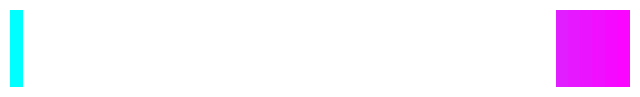

In [12]:
num_colors = min(labels)
total_colors = max(labels) - min(labels) + 1 


base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors
new_colors = black_section + colors

MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

colors_section = new_colors[num_colors:]  

for i in range(1, len(colors_section)-6):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM_SELECTED = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM_SELECTED)
plt.axis("off")
plt.show()

In [13]:
custom_cmap = ListedColormap(
    ["#ffffff", "#ff0000"],
    name="custom",
)

custom_cmap_4 = ListedColormap(
    ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
    name="bright_contrast"
)

custom_cmap_6 = ListedColormap(
    ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
    name="dramatic6"
)

labels_ = list(set(labels))
labels_.sort()
year_label = [[y, str(y)] for y in labels_]

map_original_y = [
    [0, 'Non-Toxic (y=0)'],
    [1, 'Toxic (y=1)']
]

map_tested_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Test - Actual Non-Toxic (y=0)'],
    [3, 'Test - Actual Toxic (y=1)']
]

map_predicted_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Predicted Non-Toxic'],
    [3, 'Predicted Toxic']
]

map_result_labels = [
    [0, 'Train Data (y=0)'],
    [1, 'Train Data (y=1)'],
    [2, 'Correctly Predicted Non-Toxic (TN)'],
    [3, 'Correctly Predicted Toxic (TP)'],
    [4, 'Incorrectly Predicted Toxic (FP)'],  
    [5, 'Incorrectly Predicted Non-Toxic (FN)'] 
]

In [16]:
X = ecfps
y = toxs

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test)]

original_y_list = list(y)
train_y_list = list(y_train) 
test_y_list = list(y_pred)  

tested_y_list = []
for pred_val in y_test:
    if pred_val >= 0.5:
        tested_y_list.append(3)
    else:
        tested_y_list.append(2)
tested_y_list = train_y_list + tested_y_list

predicted_y_list = []
for pred_val in y_pred:
    if pred_val >= 0.5:
        predicted_y_list.append(3)
    else:
        predicted_y_list.append(2)
predicted_y_list = train_y_list + predicted_y_list

result_labels = []
for true_val, pred_val in zip(y_test, y_pred):
    pred_val_rounded = round(pred_val) 
    if true_val == pred_val_rounded and true_val == 1:
        result_labels.append(3)
    elif true_val == pred_val_rounded and true_val == 0:
        result_labels.append(2)
    elif pred_val_rounded == 0:
        result_labels.append(5) 
    else:
        result_labels.append(4) 
result_labels = train_y_list + result_labels

In [14]:
smiles_s = [] 
years_s = []  
ecfps_s = [] 
toxs_s = []  

for i in trange(len(df)):
    smiles_s.append(df.iloc[i, 0])
    years_s.append(int(df.iloc[i, 2]))
    ecfps_s.append(compute_ecfp(df.iloc[i, 0])) 
    toxs_s.append(df.iloc[i, 1])  

# X_s = ecfps_s
# y_s = toxs_s

# X_train_s, X_test_s, y_train_s, y_test_s, train_indices_s, test_indices_s = train_test_split(
#     X_s, y_s, range(len(X_s)), test_size=0.3, shuffle=True
# )

# smiles_train_s = [smiles_s[i] for i in train_indices_s]
# smiles_test_s = [smiles_s[i] for i in test_indices_s]
# years_train_s = [years_s[i] for i in train_indices_s]
# years_test_s = [years_s[i] for i in test_indices_s]

# le = LabelEncoder()
# y_train_encoded_s = le.fit_transform(y_train_s)

# model = xgb.XGBClassifier()
# model.fit(X_train_s, y_train_encoded_s)

# y_pred_s = model.predict(X_test_s)

# r2_s = r2_score(y_test_s, y_pred_s)
# mse_s = mean_squared_error(y_test_s, y_pred_s)
# mae_s = mean_absolute_error(y_test_s, y_pred_s)
# result_s = [
#     "time",
#     r2_s,
#     mse_s,
#     mae_s,
#     sum(y_s) / len(y_s),
#     sum(y_train_s) / len(y_train_s),
#     sum(y_test_s) / len(y_test_s),
# ]

# n_samples = len(smiles_s)
# tested_y_list_ordered = [None] * n_samples
# predicted_y_list_ordered = [None] * n_samples
# result_labels_ordered = [None] * n_samples

# train_y_list_s = y_train_s

# for i, idx in enumerate(train_indices_s):
#     tested_y_list_ordered[idx] = train_y_list_s[i]
#     predicted_y_list_ordered[idx] = train_y_list_s[i]
#     result_labels_ordered[idx] = train_y_list_s[i]   

# for i, idx in enumerate(test_indices_s):
#     tested_y_list_ordered[idx] = 3 if y_test_s[i] >= 0.5 else 2
#     predicted_y_list_ordered[idx] = 3 if y_pred_s[i] >= 0.5 else 2

#     pred_val_rounded = round(y_pred_s[i])
#     if y_test_s[i] == pred_val_rounded and y_test_s[i] == 1:
#         result_labels_ordered[idx] = 3
#     elif y_test_s[i] == pred_val_rounded and y_test_s[i] == 0:
#         result_labels_ordered[idx] = 2
#     elif pred_val_rounded == 0: #
#         result_labels_ordered[idx] = 5                       
#     else:
#         result_labels_ordered[idx] = 4

  0%|          | 0/6716 [00:00<?, ?it/s]

In [18]:
y_prob = model.predict_proba(X_test)
auroc = roc_auc_score(y_test, y_prob[:, 1])
y_prob_s = model.predict_proba(X_test_s)
auroc_s = roc_auc_score(y_test_s, y_prob_s[:, 1])
result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test), auroc]
print(f"auroc: {auroc}")
result_s = ["time", r2_s, mse_s, mae_s, sum(y_s)/len(y_s), sum(y_train_s)/len(y_train_s), sum(y_test_s)/len(y_test_s), auroc_s]
print(f"auroc (shuffle): {auroc_s}")

auroc: 0.9506054952476188
auroc (shuffle): 0.8725922813959356


In [16]:
# categorical_maps_list = [
#     year_label,              
#     year_label,                   
#     map_original_y,         
#     map_tested_y,           
#     map_predicted_y,        
#     map_result_labels       
# ]

categorical_maps_list = [
    year_label,              
    year_label,             
]

In [17]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    # {"x": x, "y": y, "c": [labels, labels, original_y_list, tested_y_list_ordered, predicted_y_list_ordered, result_labels_ordered], "labels": smiles},
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    # colormap=[MY_CM, MY_CM_3, custom_cmap, custom_cmap_4, custom_cmap_4, custom_cmap_6],
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year_2", "Original Y", "Tested Y", "Predicted Y", "Result Type"], 
    categorical=[True, True, True, True, True, True],
    legend_labels=categorical_maps_list,
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("tdc_12_hERG", template="smiles")

/workspace/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/notebook/experiment/tdc_12_hERG.html

In [18]:
def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t])
    purity = np.sum(matches) / len(matches)
    return purity

labels = np.array(labels) 
lsh_purity_real = lsh_forest_purity(s, t, labels)

num_permutations = 1000
random_purities = []

for _ in trange(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
p_value = np.mean(random_purities >= lsh_purity_real)


print(f"LSH Forest Edge Homophily Ratio (Real): {lsh_purity_real:.4f}")
print(f"Mean Random Homophily Ratio: {random_purities.mean():.4f}")
print(f"p-value: {p_value:.4f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

LSH Forest Edge Homophily Ratio (Real): 0.5266
Mean Random Homophily Ratio: 0.0612
p-value: 0.0000


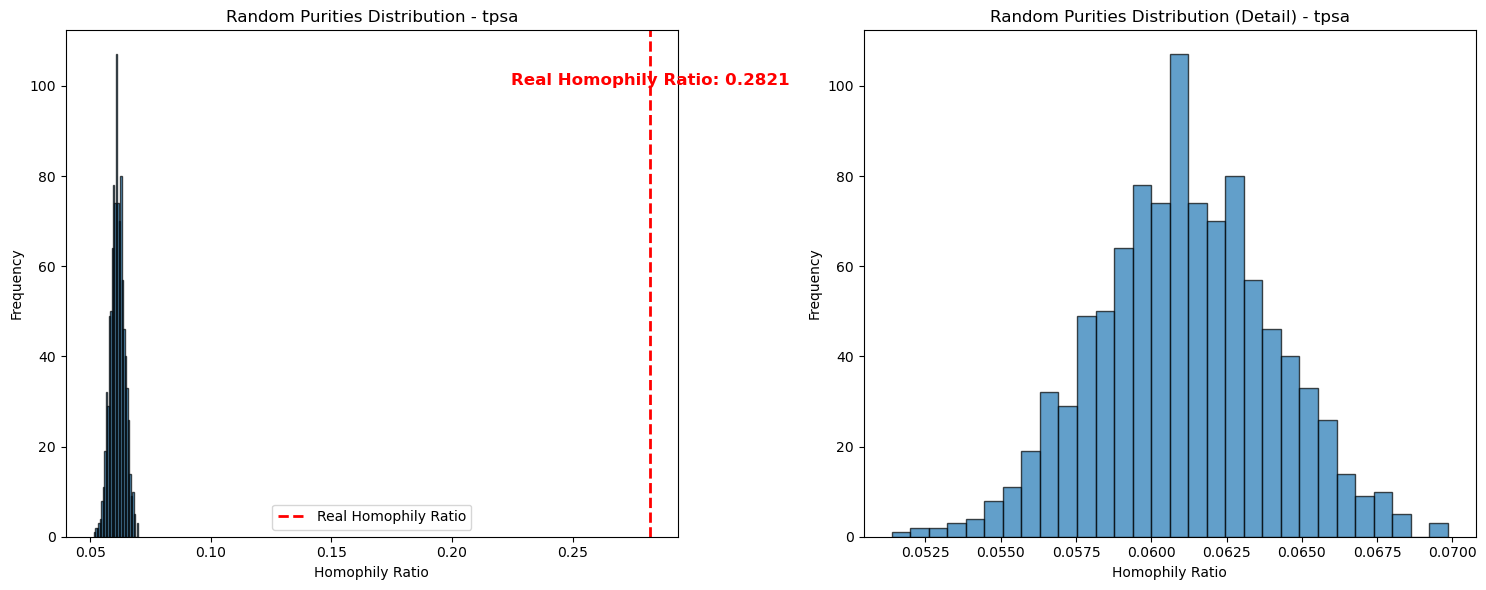

<built-in function id> 0.0 tpsa


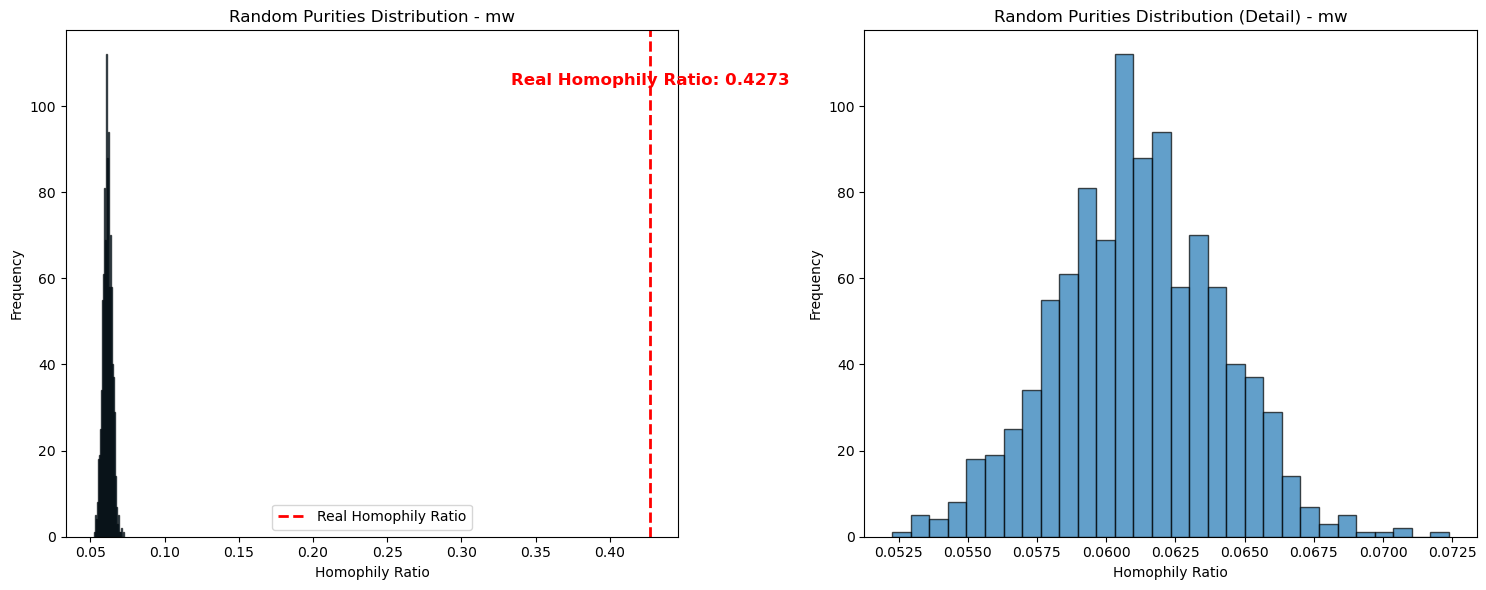

<built-in function id> 0.0 mw


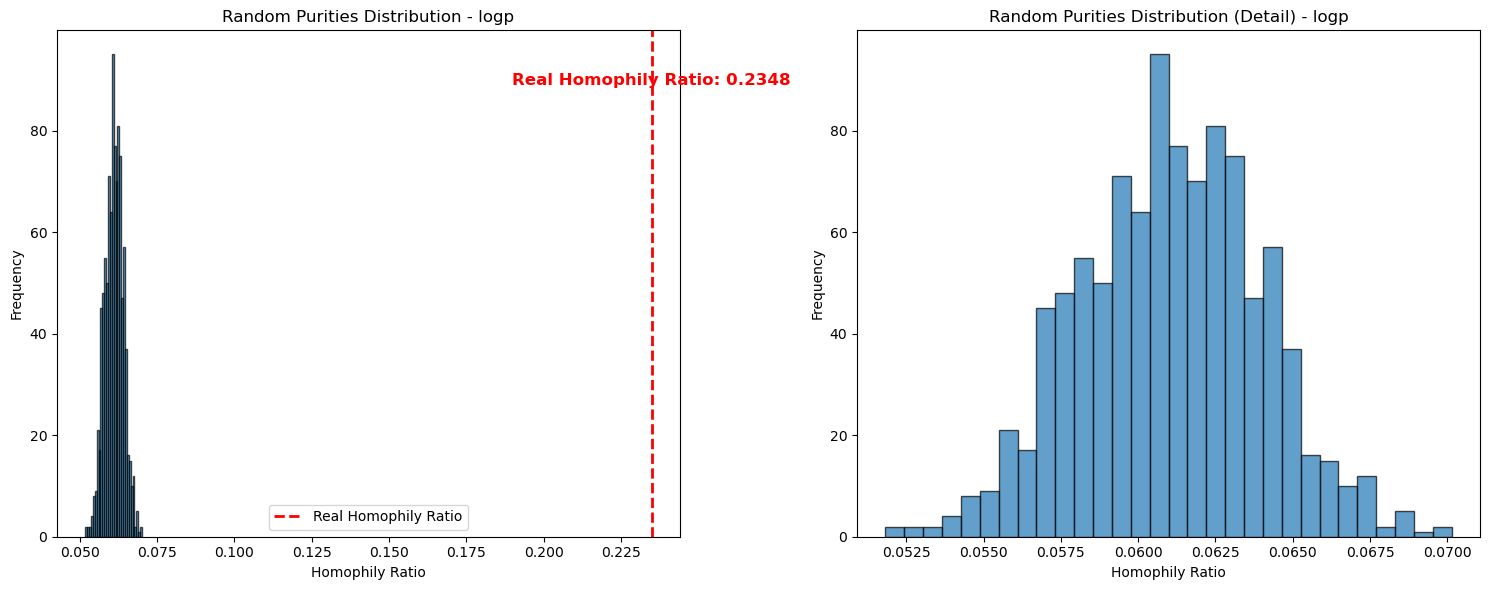

<built-in function id> 0.0 logp


In [19]:
scores = []
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Purities Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

# make tmap - all tdc's classification task

In [20]:
paths = glob.glob("../../data/processed/tdc/*/*_date.tsv")
df_details = pd.read_csv("../../data/processed/tdc/details.tsv", sep='\t', header=None)

In [21]:
tasks = {}
for i in range(len(df_details)):
    name = df_details.iloc[i, 1]
    task_type = df_details.iloc[i, 5]
    tasks[name] = task_type

classification_paths = []
for path in paths:
    task_name = os.path.basename(path).replace("_date.tsv", "")
    if tasks[task_name] != 2:
        continue
    else:
        classification_paths.append(path)

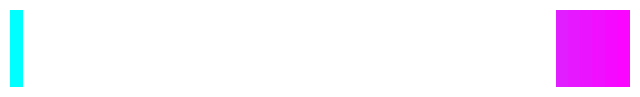

In [22]:
labels = []
for year in years:
    labels.append(year)

num_colors = min(labels)
total_colors = max(labels) - min(labels) + 1 


base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors
new_colors = black_section + colors

MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

colors_section = new_colors[num_colors:]  

for i in range(1, len(colors_section)-6):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM_SELECTED = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM_SELECTED)
plt.axis("off")
plt.show()

custom_cmap = ListedColormap(
    ["#ffffff", "#ff0000"],
    name="custom",
)

custom_cmap_4 = ListedColormap(
    ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
    name="bright_contrast"
)

custom_cmap_6 = ListedColormap(
    ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
    name="dramatic6"
)

map_original_y = [
    [0, 'Non-Toxic (y=0)'],
    [1, 'Toxic (y=1)']
]

map_tested_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Test - Actual Non-Toxic (y=0)'],
    [3, 'Test - Actual Toxic (y=1)']
]

map_predicted_y = [
    [0, 'Train (y=0)'],
    [1, 'Train (y=1)'],
    [2, 'Predicted Non-Toxic'],
    [3, 'Predicted Toxic']
]

map_result_labels = [
    [0, 'Train Data (y=0)'],
    [1, 'Train Data (y=1)'],
    [2, 'Correctly Predicted Non-Toxic (TN)'],
    [3, 'Correctly Predicted Toxic (TP)'],
    [4, 'Incorrectly Predicted Toxic (FP)'],  
    [5, 'Incorrectly Predicted Non-Toxic (FN)'] 
]


In [23]:
df

,smiles,tox,year
0,CCC1(c2ccccc2)C(=O)NC(=O)NC1=O,0,1973.044
1,CC(=O)Oc1ccccc1C(=O)O,0,1973.044
2,CN1CCCC1c1cccnc1,0,1973.101
3,CCN(CC)CCNC(=O)c1ccc(N)cc1,0,1973.121
4,COC(=O)[C@H]1[C@H]2C[C@@H]3c4[nH]c5cc(OC)ccc5c...,1,1973.236
...,...,...,...
6711,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCCC)c(I)c1,0,2023.551
6712,[O-][n+]1cccc(CC(c2ccc(OC(F)F)c(OC3CC3)c2)c2cn...,0,2023.608
6713,Cc1ccc(-n2[nH]c(C)c(N=Nc3cccc(-c4cccc(C(=O)O)c...,0,2023.877
6714,O=[N+]([O-])c1cn2c(n1)OC[C@H](Oc1ccc(OC(F)(F)F...,0,2023.915


Feature Calculation:   0%|          | 0/5715 [00:00<?, ?it/s]

/workspace/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/3_HIV/tmap.html

Purity for 'year_full': Real=0.1271, p-value=0.0000
Purity for 'year_binned': Real=0.5940, p-value=0.0000
Homophily Ratio for 'tpsa': Real=0.2387, p-value=0.0000
Homophily Ratio for 'mw': Real=0.1120, p-value=0.0000
Homophily Ratio for 'logp': Real=0.1250, p-value=0.0000


/tmp/ipykernel_152931/1712090940.py:263: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_152931/1712090940.py:324: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


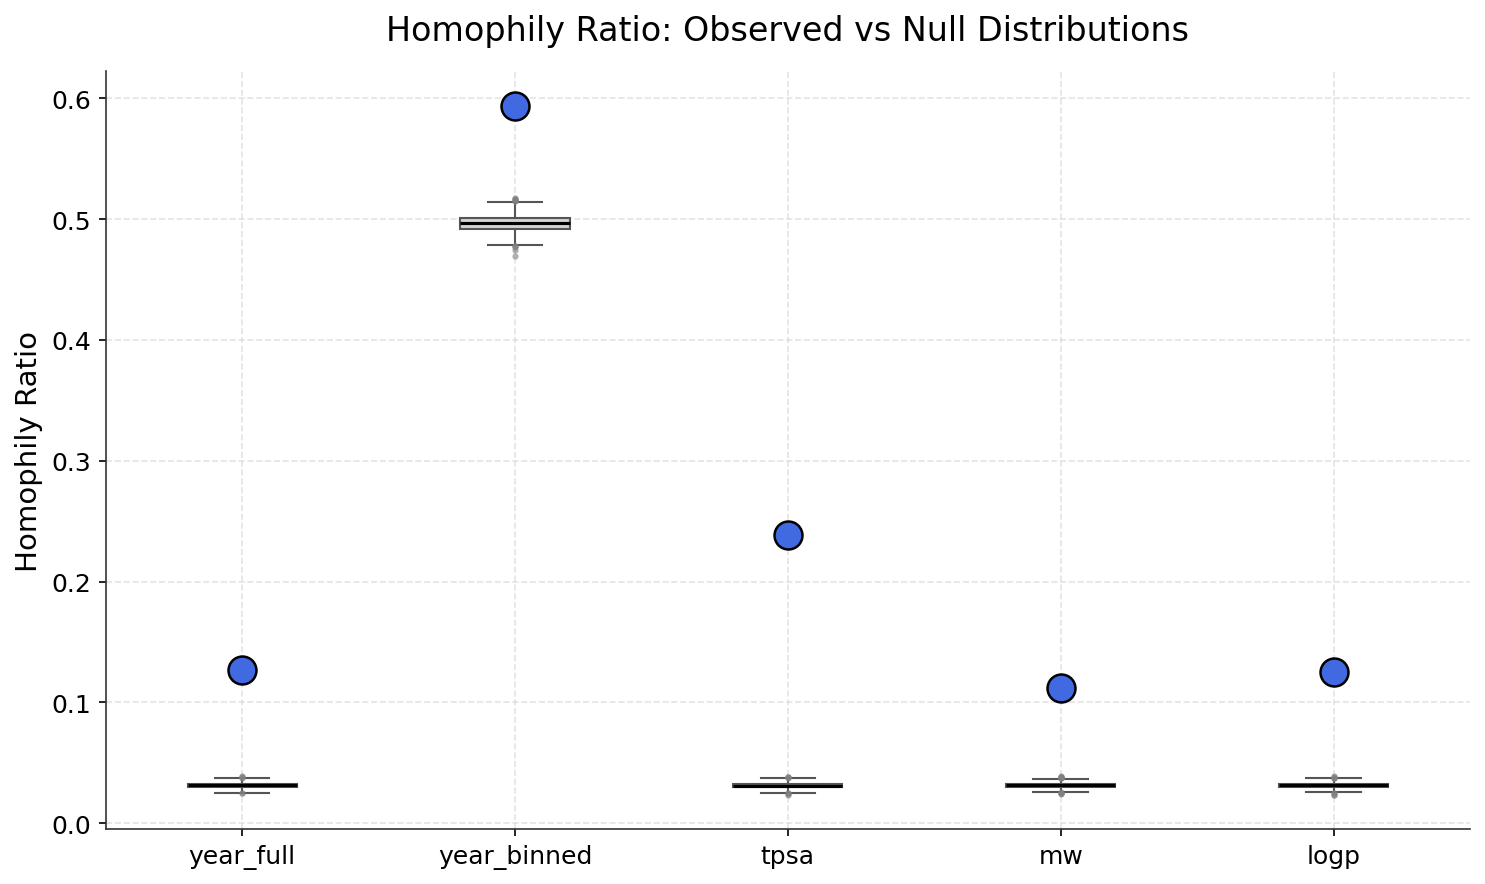

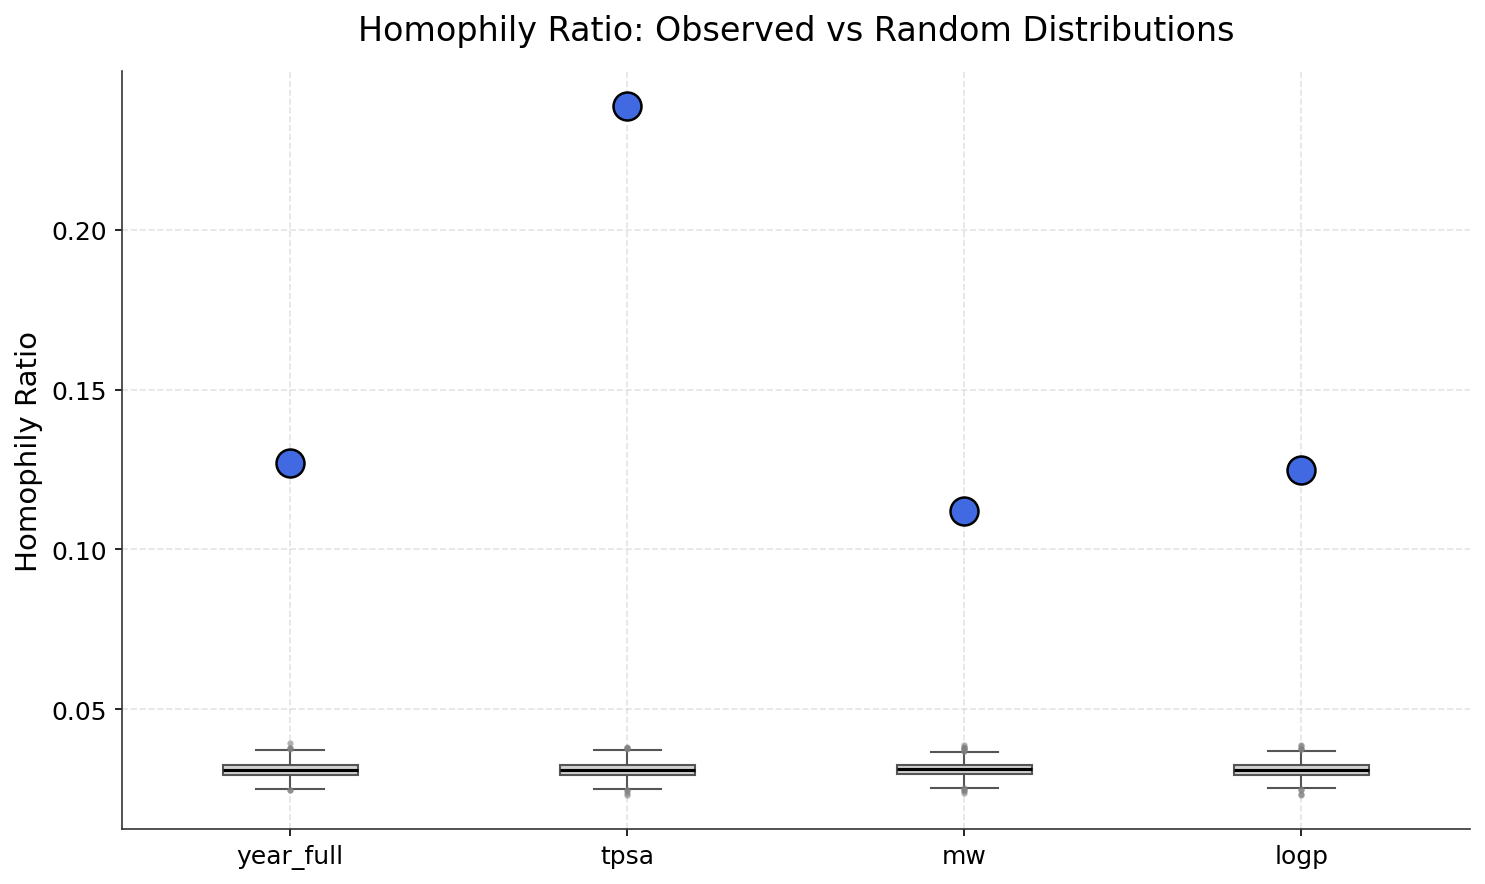

In [ ]:
scores = []
num_permutations = 1000

for i in range(len(classification_paths)):
    task_name = os.path.basename(classification_paths[i]).replace('_date.tsv', '')
    if task_name != "3_HIV":
        continue
    output_folder_path = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/{task_name}"
    os.makedirs(output_folder_path, exist_ok=True)
    for filename in os.listdir(output_folder_path):
        file_path = os.path.join(output_folder_path, filename)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            import shutil
            shutil.rmtree(file_path)

    df = pd.read_csv(classification_paths[i], sep='\t', header=0, names=['smiles', 'tox', 'year'])
    df = df.sort_values(by='year', ascending=True).reset_index(drop=True)

    smiles, years, ecfps, toxs, tpsa, mw, logp = [], [], [], [], [], [], []
    for j in trange(len(df), desc="Feature Calculation"):
        smi = df.iloc[j, 0]
        mol = Chem.MolFromSmiles(smi)
        smiles.append(smi)
        years.append(int(df.iloc[j, 2]))
        ecfps.append(compute_ecfp(smi))
        toxs.append(df.iloc[j, 1])
        if mol:
            tpsa.append(Descriptors.TPSA(mol))
            mw.append(Descriptors.MolWt(mol))
            logp.append(Descriptors.MolLogP(mol))
        else:
            tpsa.append(0)
            mw.append(0)
            logp.append(0)

    d, n = 2048, len(ecfps)
    enc_tm = tm.Minhash(256)
    lf_tm = tm.LSHForest(256)
    ecfp_data_tm = [tm.VectorUchar(np.array(fp)) for fp in ecfps]
    lf_tm.batch_add(enc_tm.batch_from_binary_array(ecfp_data_tm))
    lf_tm.index()
    knng_from, knng_to, knng_weight = tm.VectorUint(), tm.VectorUint(), tm.VectorFloat()
    _ = lf_tm.get_knn_graph(knng_from, knng_to, knng_weight, 10)
    x_tm, y_tm, s_tm, t_tm, _ = tm.layout_from_lsh_forest(lf_tm)

    X_ts, y_ts = ecfps, toxs
    X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.3, shuffle=False)
    le_ts = LabelEncoder()
    y_train_encoded_ts = le_ts.fit_transform(y_train_ts)
    model_ts = xgb.XGBClassifier(random_state=42)
    model_ts.fit(X_train_ts, y_train_encoded_ts)
    y_pred_ts = model_ts.predict(X_test_ts)
    predicted_y_list_ordered_ts = [None] * len(smiles)

    for i in range(len(y_train_encoded_ts)):
        predicted_y_list_ordered_ts[i] = y_train_encoded_ts[i]

    # テストデータ部分には、予測値ラベル (2 or 3) を入れる
    for i, pred_val in enumerate(y_pred_ts):
        # インデックスは訓練データの直後から始まる
        idx = len(y_train_encoded_ts) + i
        predicted_y_list_ordered_ts[idx] = 3 if pred_val >= 0.5 else 2

    result_labels_timesplit = [None] * len(smiles)
    for train_idx in range(len(y_train_encoded_ts)):
        result_labels_timesplit[train_idx] = y_train_encoded_ts[train_idx]
    for test_idx, (true_val, pred_val) in enumerate(zip(y_test_ts, y_pred_ts)):
        pred_rounded = round(pred_val)
        idx = len(y_train_ts) + test_idx
        if true_val == pred_rounded and true_val == 1: result_labels_timesplit[idx] = 3 # TP
        elif true_val == pred_rounded and true_val == 0: result_labels_timesplit[idx] = 2 # TN
        elif pred_rounded == 0: result_labels_timesplit[idx] = 5 # FN
        else: result_labels_timesplit[idx] = 4 # FP

    X_rs, y_rs = ecfps, toxs
    X_train_rs, X_test_rs, y_train_rs, y_test_rs, train_indices_rs, test_indices_rs = train_test_split(
        X_rs, y_rs, range(len(X_rs)), test_size=0.3, shuffle=True, random_state=42
    )
    le_rs = LabelEncoder()
    y_train_encoded_rs = le_rs.fit_transform(y_train_rs)
    model_rs = xgb.XGBClassifier(random_state=42)
    model_rs.fit(X_train_rs, y_train_encoded_rs)
    y_pred_rs = model_rs.predict(X_test_rs)

    predicted_y_list_ordered_rs = [None] * len(smiles)
    result_labels_ordered_rs = [None] * len(smiles)
    for i, idx in enumerate(train_indices_rs):
        predicted_y_list_ordered_rs[idx] = y_train_encoded_rs[i]
        result_labels_ordered_rs[idx] = y_train_encoded_rs[i]
    for i, idx in enumerate(test_indices_rs):
        predicted_y_list_ordered_rs[idx] = 3 if y_pred_rs[i] >= 0.5 else 2
        pred_rounded = round(y_pred_rs[i])
        if y_test_rs[i] == pred_rounded and y_test_rs[i] == 1: result_labels_ordered_rs[idx] = 3 # TP
        elif y_test_rs[i] == pred_rounded and y_test_rs[i] == 0: result_labels_ordered_rs[idx] = 2 # TN
        elif pred_rounded == 0: result_labels_ordered_rs[idx] = 5 # FN
        else: result_labels_ordered_rs[idx] = 4 # FP

    labels_year_full = [y for y in years]
    labels_year_binned = [0 if y <= 1990 else 2 if y >= 2023 else 1 for y in years]

    true_y_list_ordered_rs = y_rs
    true_y_list_ordered_ts = y_ts

    map_year_binned = {0: 'Until 1990', 1: '1991-2022', 2: 'From 2023'}
    map_toxicity = {0: 'Non-toxic', 1: 'Toxic'}
    map_predicted = {0: 'Train (Non-toxic)', 1: 'Train (Toxic)', 2: 'Pred (Non-toxic)', 3: 'Pred (Toxic)'}
    map_results = {0: 'Train (Non-toxic)', 1: 'Train (Toxic)', 2: 'True Negative', 3: 'True Positive', 4: 'False Positive', 5: 'False Negative'}

    legend_map_year_binned = [[k, v] for k, v in map_year_binned.items()]
    legend_map_toxicity = [[k, v] for k, v in map_toxicity.items()]
    legend_map_predicted = [[k, v] for k, v in map_predicted.items()]
    legend_map_results = [[k, v] for k, v in map_results.items()]
    labels_year_full_set = sorted(set(labels_year_full))
    year_label = [[y, str(y)] for y in labels_year_full_set]

    labels = []
    for year in years:
        labels.append(year)

    num_colors = min(labels)
    total_colors = max(labels) - min(labels) + 1 

    base_cmap = plt.get_cmap("cool")
    colors = [base_cmap(i / total_colors) for i in range(total_colors)]

    black_section = [(0, 0, 0, 0)] * num_colors
    new_colors = black_section + colors

    MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

    colors_section = new_colors[num_colors:]  

    for i in range(1, len(colors_section)-6):
        colors_section[i] = (0, 0, 0, 0)

    new_colors[num_colors:] = colors_section

    MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

    gradient = np.linspace(0, 1, 256).reshape(1, -1)

    custom_cmap = ListedColormap(
        ["#ffffff", "#ff0000"],
        name="custom",
    )

    custom_cmap_4 = ListedColormap(
        ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],
        name="bright_contrast"
    )

    custom_cmap_6 = ListedColormap(
        ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
        name="dramatic6"
    )

    legend_labels_list = [
        year_label,                   
        year_label,  
        legend_map_toxicity,        
        legend_map_toxicity,
        legend_map_toxicity,   
        legend_map_predicted,      
        legend_map_predicted,   
        legend_map_results,         
        legend_map_results           
    ]

    task_name = task_name[2:]
    faerun = Faerun(clear_color="#111111", view="front", coords=False)
    faerun.add_scatter(
        task_name,
        {"x": x_tm, "y": y_tm, "labels": smiles,
            "c": [labels_year_full, labels_year_full, toxs, true_y_list_ordered_rs, true_y_list_ordered_ts,
                predicted_y_list_ordered_rs, predicted_y_list_ordered_ts, result_labels_ordered_rs, result_labels_timesplit]},
        shader="smoothCircle",
        series_title=["Year (Full)", "Year (Binned)", "Original Y", "True Y (Random Split)",
                    "True Y (Time Split)", "Predicted Y (Random)", "Predicted Y (Time Split)", "Result (Random)", "Result (Time-based)"],
        categorical=[True, True, True, True, True, True, True, True, True],
        legend_labels=legend_labels_list,
        colormap=[MY_CM, MY_CM_3, custom_cmap, custom_cmap, custom_cmap, custom_cmap_4, custom_cmap_4, custom_cmap_6, custom_cmap_6],
        point_scale=2.5,
        max_point_size=20,
        has_legend=True,
    )
    faerun.add_tree(
        f"{task_name}_tree", {"from": s_tm, "to": t_tm}, point_helper=task_name, color="#666666"
    )

    faerun.plot(f"{output_folder_path}/tmap", template="smiles")

    plot_labels = []   
    plot_nulls = []   
    plot_reals = []   

    for labels_data, label_type in [(np.array(labels_year_full), "year_full"), (np.array(labels_year_binned), "year_binned")]:
        plot_labels.append(label_type)
        purity_real = lsh_forest_purity(s_tm, t_tm, labels_data)
        random_purities = [lsh_forest_purity(s_tm, t_tm, np.random.permutation(labels_data)) for _ in range(num_permutations)]
        p_value = np.mean(np.array(random_purities) >= purity_real)
        scores.append([task_name, p_value, label_type])
        plot_nulls.append(random_purities)
        plot_reals.append(purity_real)
        print(f"Purity for '{label_type}': Real={purity_real:.4f}, p-value={p_value:.4f}")

        plt.figure(figsize=(8, 6))
        plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random Permutations (N={num_permutations})')
        plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real Homophily Ratio: {purity_real:.4f}')
        plt.title(f"Homophily Ratio Distribution - {task_name} - {label_type}")
        plt.xlabel("Homophily Ratio"), plt.ylabel("Frequency"), plt.legend()
        plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png"), plt.close()
        result_data = {
            "dataset_id": task_name,
            "feature": label_type,
            "real_hr": purity_real,
            "null_distribution": random_purities,
            "p_value": p_value
        }
        pickle_path = os.path.join(output_folder_path, f"homophily_data_{label_type}.pkl")
        with open(pickle_path, "wb") as f:
            pickle.dump(result_data, f)

    year_counts = list(collections.Counter(sorted(years)).values())
    for prop_data, prop_name in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        plot_labels.append(prop_name)
        sorted_indices = np.argsort(prop_data)
        prop_labels = np.zeros(len(prop_data), dtype=int)
        current_label, current_index = 0, 0
        for count in year_counts:
            indices_to_label = sorted_indices[current_index : current_index + count]
            prop_labels[indices_to_label] = current_label
            current_index += count
            current_label += 1
        
        purity_real = lsh_forest_purity(s_tm, t_tm, prop_labels)
        random_purities = [lsh_forest_purity(s_tm, t_tm, np.random.permutation(prop_labels)) for _ in range(num_permutations)]
        p_value = np.mean(np.array(random_purities) >= purity_real)
        scores.append([task_name, p_value, prop_name])
        plot_nulls.append(random_purities)
        plot_reals.append(purity_real)
        print(f"Homophily Ratio for '{prop_name}': Real={purity_real:.4f}, p-value={p_value:.4f}")

        plt.figure(figsize=(8, 6))
        plt.hist(random_purities, bins=30, edgecolor='black', alpha=0.7, label=f'Random Permutations (N={num_permutations})')
        plt.axvline(purity_real, color='red', linestyle='dashed', linewidth=2, label=f'Real Homophily Ratio: {purity_real:.4f}')
        plt.title(f"Homophily Ratio Distribution - {task_name} - {prop_name}"), plt.xlabel("Homophily Ratio"), plt.ylabel("Frequency"), plt.legend()
        plt.savefig(f"{output_folder_path}/random_homophily_ratios_{prop_name}.png"), plt.close()

        result_data = {
            "dataset_id": task_name,
            "feature": prop_name,
            "real_hr": purity_real,
            "null_distribution": random_purities,
            "p_value": p_value
        }
        pickle_path = os.path.join(output_folder_path, f"homophily_data_{prop_name}.pkl")
        with open(pickle_path, "wb") as f:
            pickle.dump(result_data, f)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    bp = ax.boxplot(
        plot_nulls,
        labels=plot_labels,
        patch_artist=True, # 箱の中を塗る
        widths=0.4,        # 箱の幅
        showfliers=True,   # 外れ値を表示(画像に合わせて点にする)
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                        linestyle='none', markeredgecolor='none', alpha=0.6)
    )

    for patch in bp['boxes']:
        patch.set_facecolor('#D3D3D3') # 薄いグレー (LightGray)
        patch.set_edgecolor('#555555') # 枠は濃いグレー
        patch.set_linewidth(1)
    
    for element in ['whiskers', 'caps']:
        plt.setp(bp[element], color='#555555', linewidth=1)
    
    plt.setp(bp['medians'], color='black', linewidth=1.5) # 中央値は黒ではっきり

    for idx, real_val in enumerate(plot_reals):
        ax.scatter(
            idx + 1, 
            real_val, 
            color='#4169E1',   # RoyalBlue (鮮やかな青)
            s=180,             # サイズ大きく
            edgecolor='black', # 黒い縁取り
            linewidth=1.2,
            zorder=10,         # 最前面に表示
            label="Real Value" if idx == 0 else None
        )

    # 3. 全体デザイン調整
    ax.set_title("Homophily Ratio: Observed vs Null Distributions", fontsize=16, pad=15)
    ax.set_ylabel("Homophily Ratio", fontsize=14)
    
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgray')
    ax.grid(axis='x', linestyle='--', alpha=0.6, color='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    plt.tight_layout()

    save_path = os.path.join(output_folder_path, "homophily_boxplot_style.png")
    plt.savefig(save_path)

    plot_nulls_2 = []
    plot_labels_2 = []
    plot_reals_2 = []
    for i in range(len(plot_labels)):
        if plot_labels[i] == "year_binned":
            continue
        plot_nulls_2.append(plot_nulls[i])
        plot_labels_2.append(plot_labels[i])
        plot_reals_2.append(plot_reals[i])

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    bp = ax.boxplot(
        plot_nulls_2,
        labels=plot_labels_2,
        patch_artist=True, # 箱の中を塗る
        widths=0.4,        # 箱の幅
        showfliers=True,   # 外れ値を表示(画像に合わせて点にする)
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                        linestyle='none', markeredgecolor='none', alpha=0.6)
    )

    for patch in bp['boxes']:
        patch.set_facecolor('#D3D3D3') # 薄いグレー (LightGray)
        patch.set_edgecolor('#555555') # 枠は濃いグレー
        patch.set_linewidth(1)
    
    for element in ['whiskers', 'caps']:
        plt.setp(bp[element], color='#555555', linewidth=1)
    
    plt.setp(bp['medians'], color='black', linewidth=1.5) # 中央値は黒ではっきり

    for idx, real_val in enumerate(plot_reals_2):
        ax.scatter(
            idx + 1, 
            real_val, 
            color='#4169E1',   # RoyalBlue (鮮やかな青)
            s=180,             # サイズ大きく
            edgecolor='black', # 黒い縁取り
            linewidth=1.2,
            zorder=10,         # 最前面に表示
            label="Real Value" if idx == 0 else None
        )

    # 3. 全体デザイン調整
    ax.set_title("Homophily Ratio: Observed vs Random Distributions", fontsize=16, pad=15)
    ax.set_ylabel("Homophily Ratio", fontsize=14)
    
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgray')
    ax.grid(axis='x', linestyle='--', alpha=0.6, color='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    save_path = os.path.join(output_folder_path, "homophily_boxplot_style_without_binned.png")
    plt.savefig(save_path)


    filepaths = {"x": f"{output_folder_path}/x.pkl", "y": f"{output_folder_path}/y.pkl",
                "s": f"{output_folder_path}/s.pkl", "t": f"{output_folder_path}/t.pkl"}
    pickle_dump(list(x_tm), filepaths["x"])
    pickle_dump(list(y_tm), filepaths["y"])
    pickle_dump(list(s_tm), filepaths["s"])
    pickle_dump(list(t_tm), filepaths["t"])

In [15]:
pd.DataFrame(scores, columns=["ID", "P-value", "Label Type"]).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig2-fig3-fig4-fig5-surechembl/scores.csv", index=False)

# make tmap for toxcast

In [20]:
df = pd.read_csv("../../data/processed/moleculenet/moleculenet_patentdate/toxcast/date_dataset.tsv", sep="\t", header=None)

In [21]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,1]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6857 [00:00<?, ?it/s]

100%|██████████| 6857/6857 [00:05<00:00, 1188.53it/s]


In [22]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

  0%|          | 0/6857 [00:00<?, ?it/s]

100%|██████████| 6857/6857 [00:13<00:00, 519.75it/s]

Generating the data took 13195.399010553956ms.
Adding the data took 6750.750042498112ms.


Indexing took 995.1974134892225ms.
make knn graph 3406.32220543921ms.


In [23]:
labels = []
for year in years:
    labels.append(year)

In [24]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year_2"], 
    categorical=[True, True],
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/tmap", template="smiles")

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/tmap.html

In [25]:
output_folder_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast"

filepaths = {
    "x": f"{output_folder_path}/x.pkl",
    "y": f"{output_folder_path}/y.pkl",
    "s": f"{output_folder_path}/s.pkl",
    "t": f"{output_folder_path}/t.pkl",
}

pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])

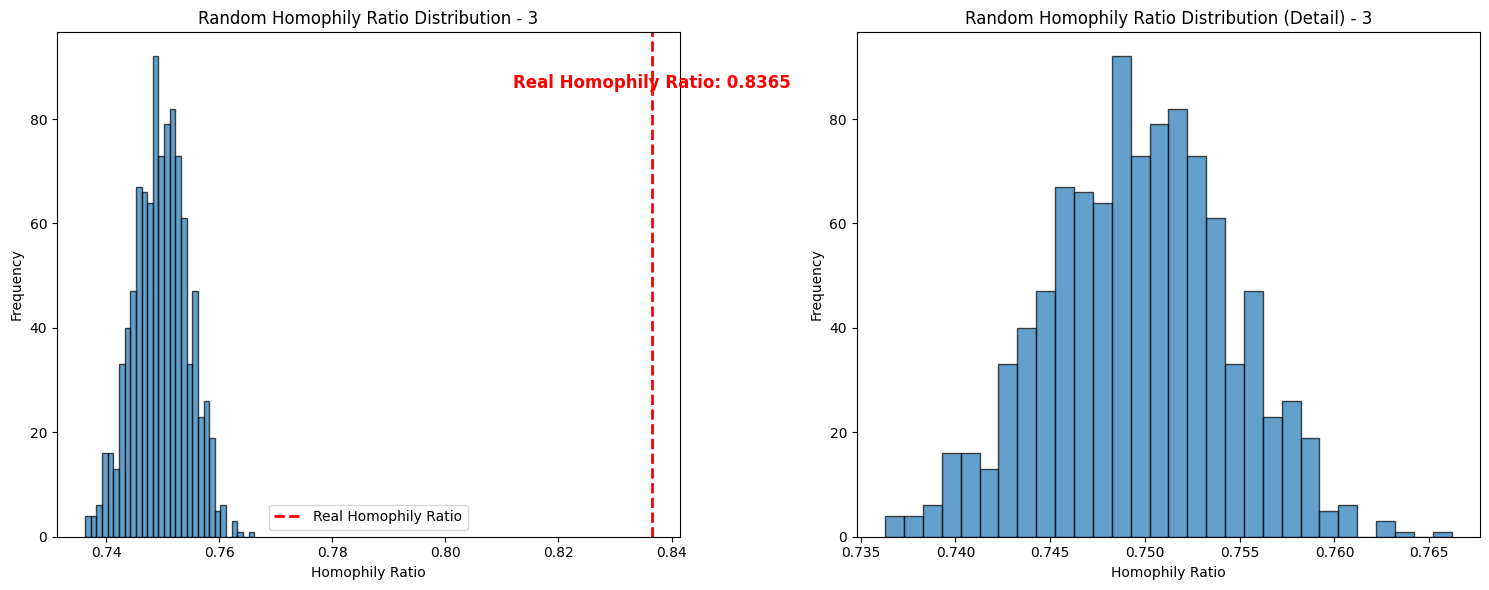

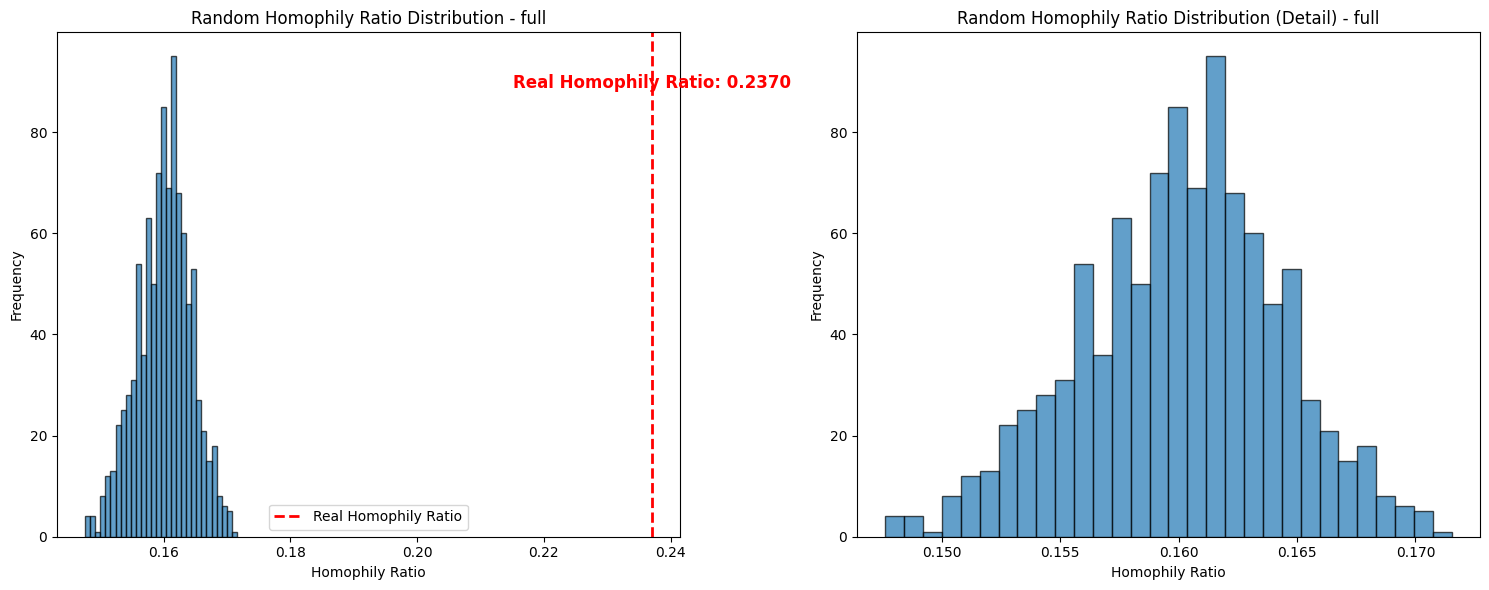

In [26]:
labels_full = [year for year in years]
labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
labels_3, labels_full = np.array(labels_3), np.array(labels_full)

scores = []
scores.append([id, lsh_forest_purity(s, t, labels_3), "3"])
scores.append([id, lsh_forest_purity(s, t, labels_full), "full"])

for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    lsh_purity_real = lsh_forest_purity(s, t, labels)
    random_purities = []
    for _ in range(num_permutations):
        shuffled_labels = np.random.permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
    
    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratio Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_purities_{label_type}.png")

    scores.append([id, p_value, label_type])

hist_3_path = os.path.join(output_folder_path, "hist_3.png")
hist_full_path = os.path.join(output_folder_path, "hist_full.png")

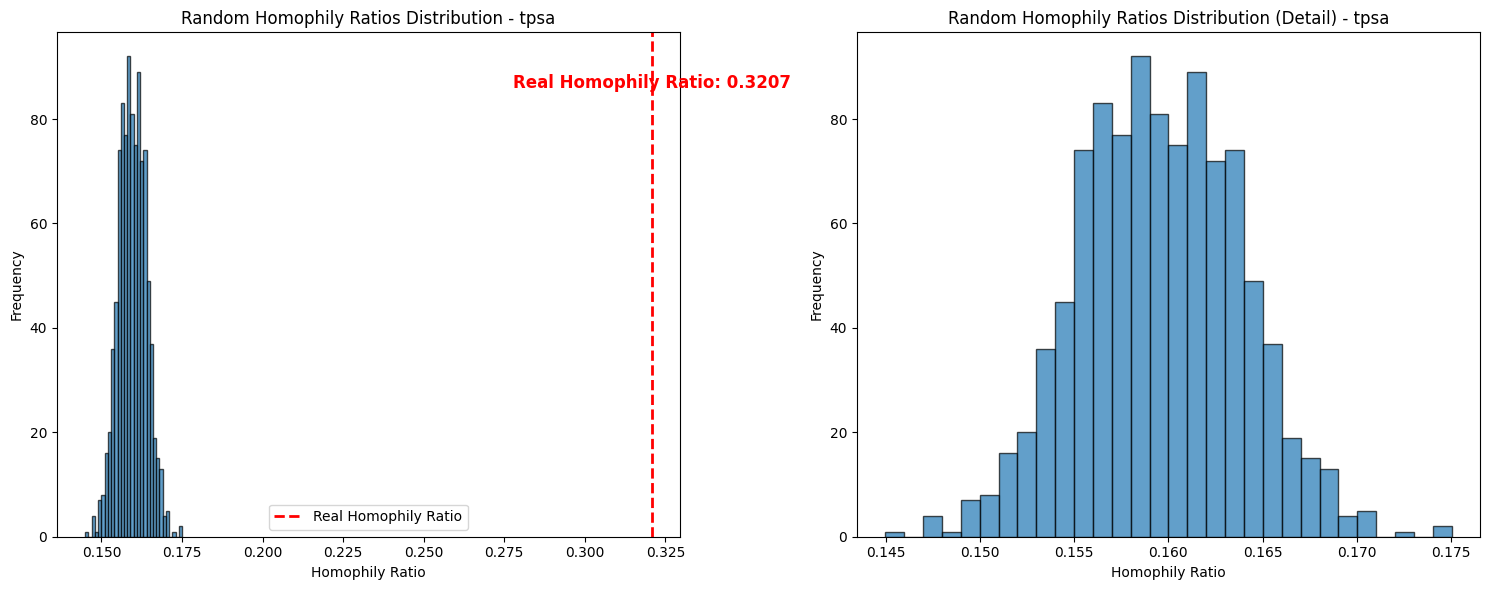

<built-in function id> 0.0 tpsa


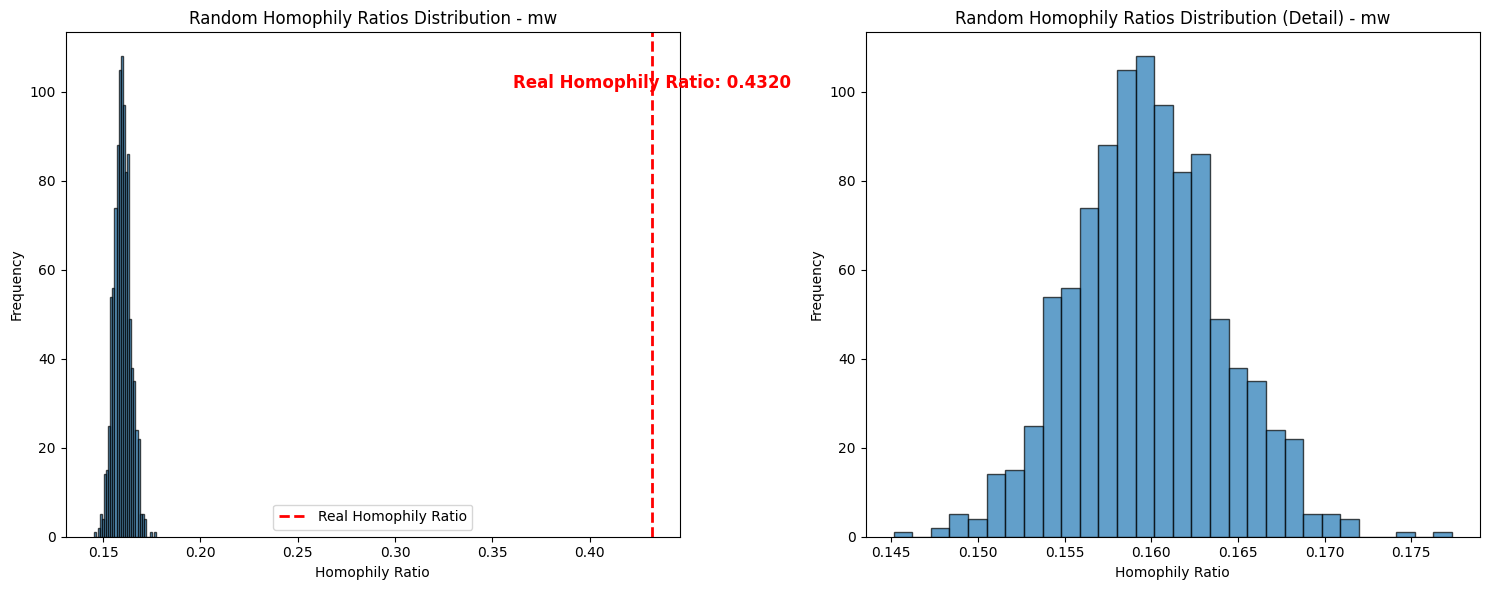

<built-in function id> 0.0 mw


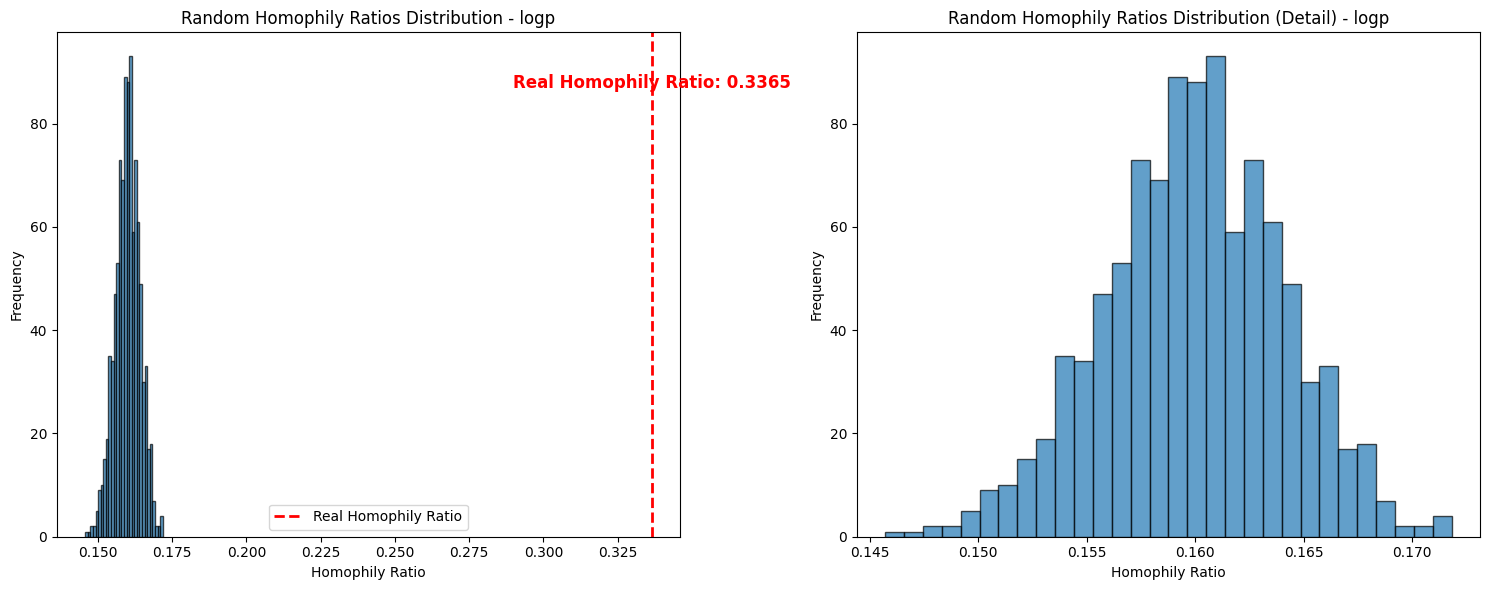

<built-in function id> 0.0 logp


In [27]:
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratios Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

In [28]:
pd.DataFrame(scores).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/toxcast/scores.csv", index=False)

# tmap for tox21

In [29]:
df = pd.read_csv("../../data/processed/moleculenet/moleculenet_patentdate/tox21/date_dataset.tsv", sep="\t", header=None)

In [30]:
smiles = []
years = []
ecfps = []
toxs = []
tpsa = []
mw = []
logp = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,1]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    mol = Chem.MolFromSmiles(df.iloc[i,0])
    tpsa.append(Descriptors.MolWt(mol))
    mw.append(Descriptors.TPSA(mol))
    logp.append(Descriptors.MolLogP(mol))

  0%|          | 0/6178 [00:00<?, ?it/s]

100%|██████████| 6178/6178 [00:04<00:00, 1311.29it/s]


In [31]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

100%|██████████| 6178/6178 [00:11<00:00, 554.90it/s]

Generating the data took 11135.438714176416ms.


Adding the data took 5143.882382661104ms.
Indexing took 700.1081462949514ms.
make knn graph 3100.2930011600256ms.


In [32]:
labels = []
for year in years:
    labels.append(year)

In [33]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    "tdc_12_hERG",
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year_2"], 
    categorical=[True, True],
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
)
faerun.add_tree(
    "tdc_12_hERG_tree", {"from": s, "to": t}, point_helper="tdc_12_hERG", color="#666666"
)

faerun.plot("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/tmap", template="smiles")

/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/tmap.html

In [34]:
output_folder_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21"

filepaths = {
    "x": f"{output_folder_path}/x.pkl",
    "y": f"{output_folder_path}/y.pkl",
    "s": f"{output_folder_path}/s.pkl",
    "t": f"{output_folder_path}/t.pkl",
}

pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])

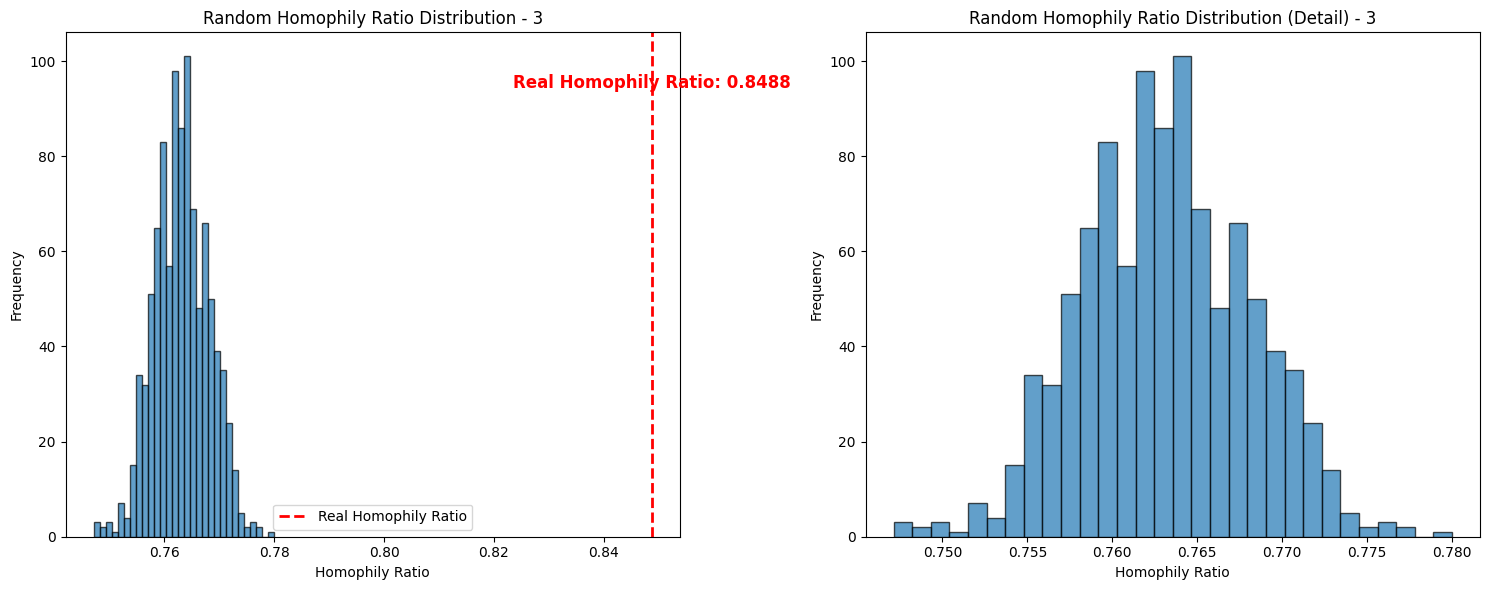

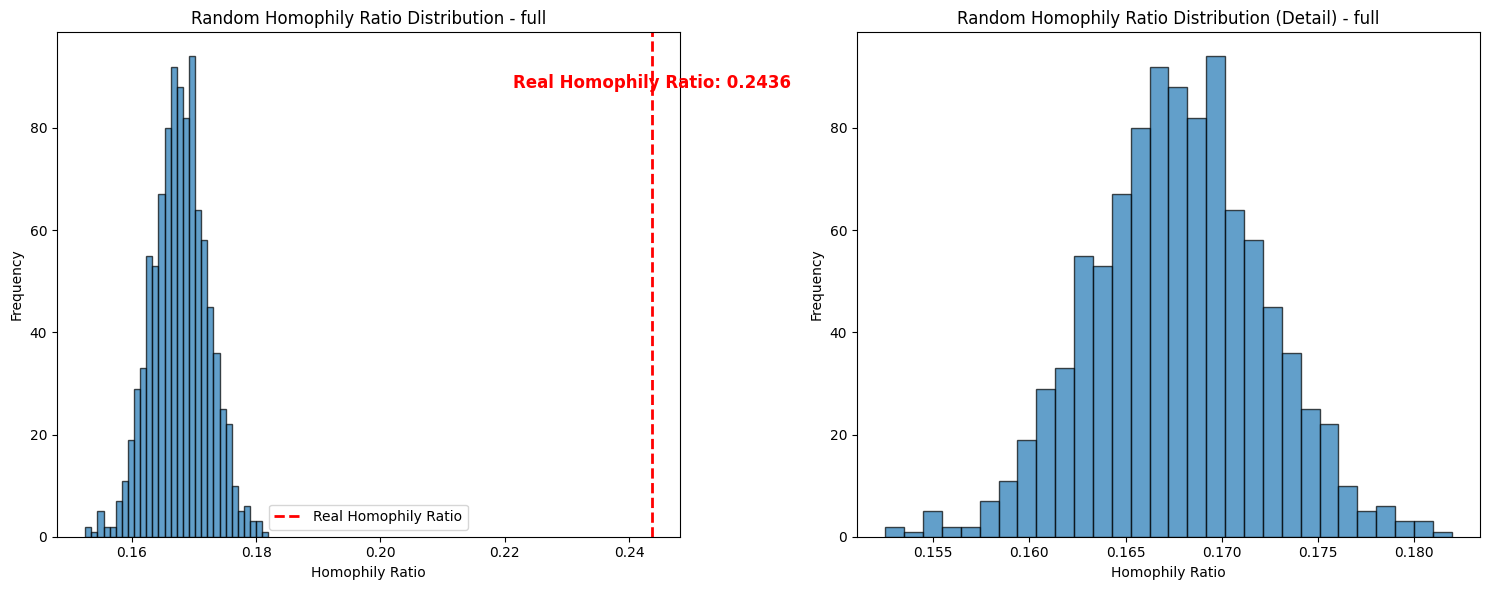

In [35]:
labels_full = [year for year in years]
labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
labels_3, labels_full = np.array(labels_3), np.array(labels_full)

scores = []
scores.append([id, lsh_forest_purity(s, t, labels_3), "3"])
scores.append([id, lsh_forest_purity(s, t, labels_full), "full"])

for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    lsh_purity_real = lsh_forest_purity(s, t, labels)
    random_purities = []
    for _ in range(num_permutations):
        shuffled_labels = np.random.permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
    
    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratio Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratio Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")

    scores.append([id, p_value, label_type])

hist_3_path = os.path.join(output_folder_path, "hist_3.png")
hist_full_path = os.path.join(output_folder_path, "hist_full.png")

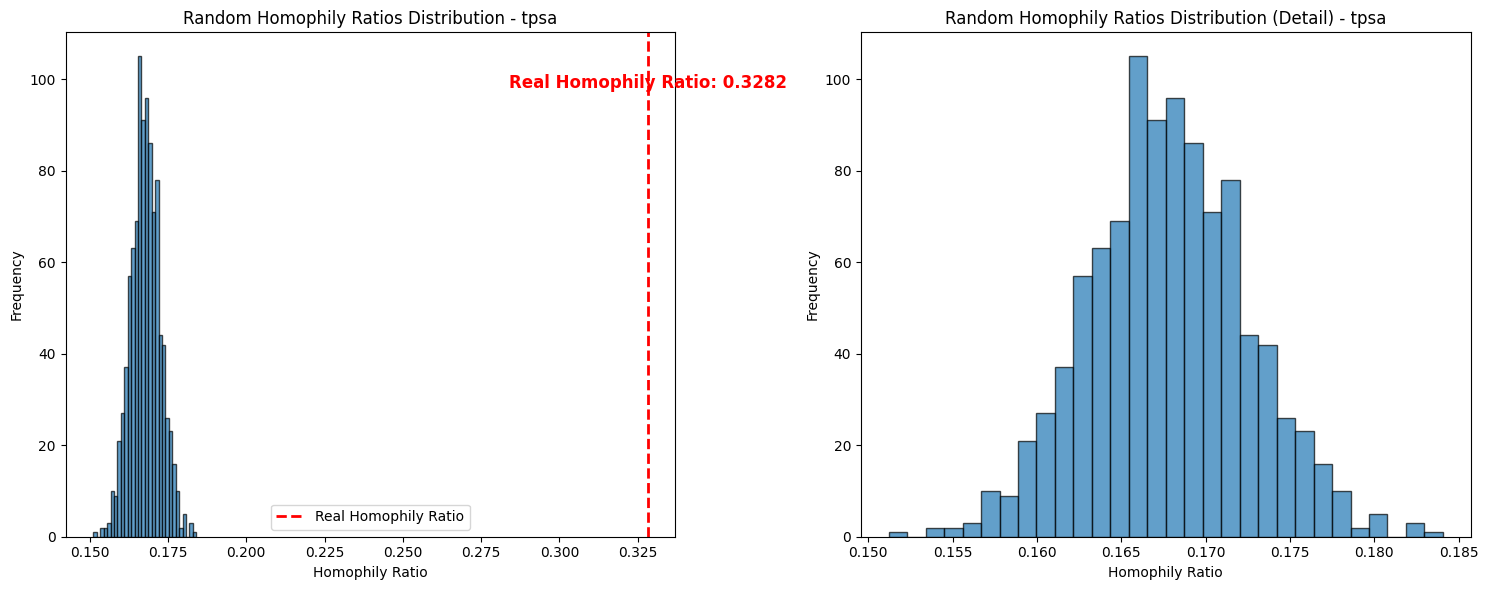

<built-in function id> 0.0 tpsa


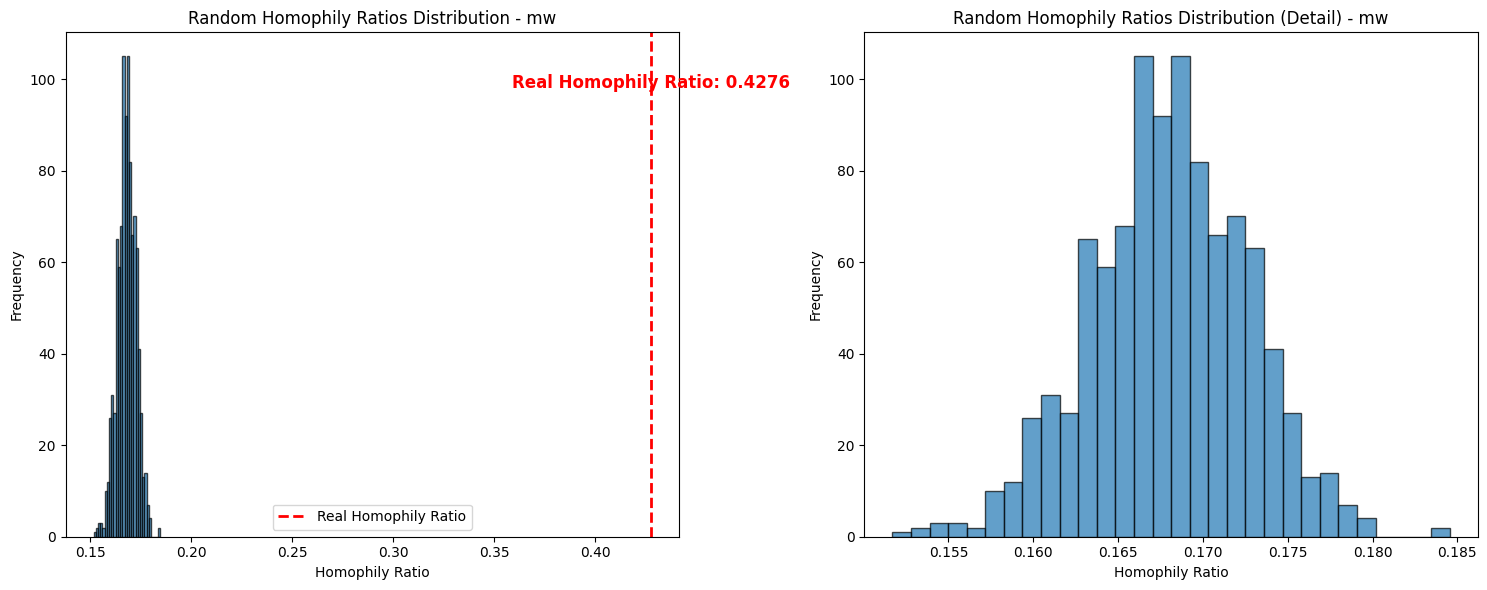

<built-in function id> 0.0 mw


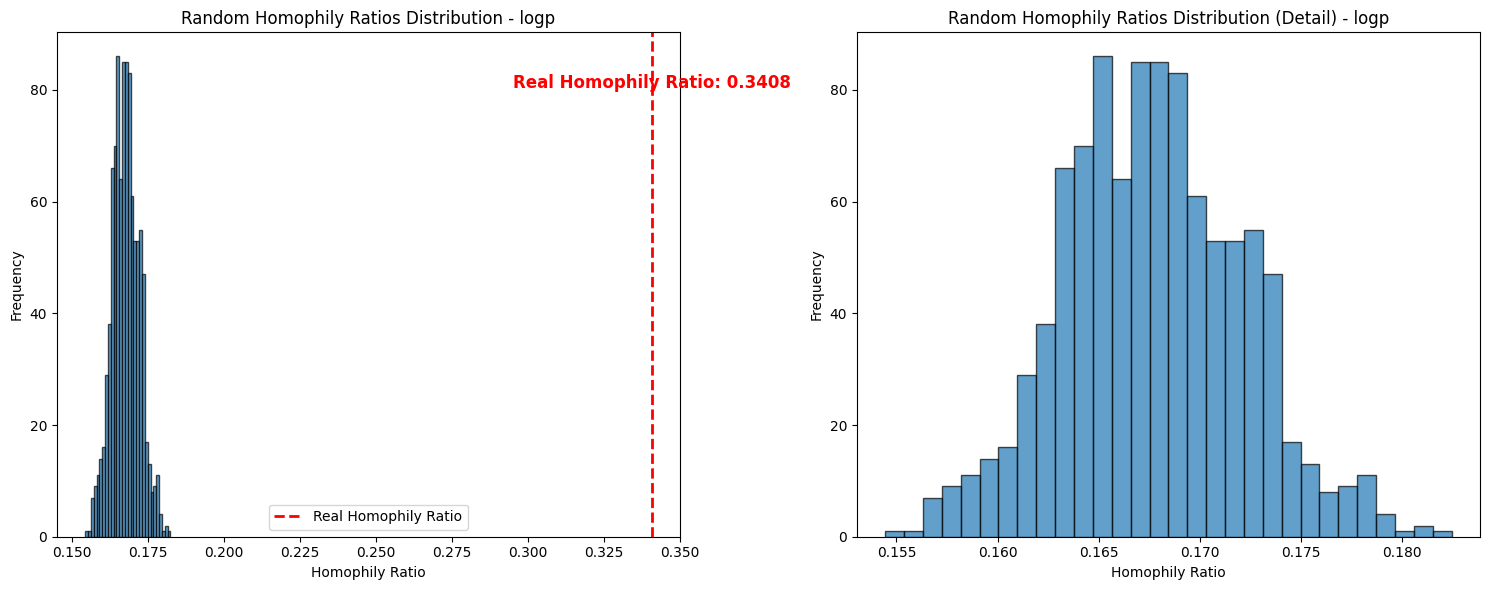

<built-in function id> 0.0 logp


In [36]:
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

count = []
for key in counter_year_keys:
    count.append(counter_year[key])

for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:  
    sorted_data = sorted(data)
    sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
    data_label = [0 for _ in range(len(data))]

    label = 0
    index = 0

    for i in count:
        index_next = index + i
        for j in range(index, index_next):
            data_label[sorted_data_index[j]] = label
        index = index_next
        label += 1

    labels = data_label
    labels = np.array(labels)

    lsh_purity_real = lsh_forest_purity(s, t, labels)

    random_purities = []

    for perm in range(num_permutations):
        shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Homophily Ratio')
    axs[0].set_title(f"Random Homophily Ratios Distribution - {label_type}")
    axs[0].set_xlabel("Homophily Ratio")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Homophily Ratio: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Homophily Ratios Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Homophily Ratio")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_folder_path}/random_homophily_ratios_{label_type}.png")
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

In [37]:
pd.DataFrame(scores).to_csv("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/tox21/scores.csv", index=False)

# homophily ratio analysis

In [14]:
homophily_labels = []
for i in range(len(classification_paths)):
    id = i
    tdc_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc"
    output_folder_path = f"{tdc_path}/{os.path.basename(classification_paths[i]).replace('_date.tsv', '')}"
    path = classification_paths[i]

    s_path = os.path.join(output_folder_path, "s.pkl")
    t_path = os.path.join(output_folder_path, "t.pkl")
    
    s = pickle_load(s_path)
    t = pickle_load(t_path)
    df = pd.read_csv(path, sep='\t')
    
    smiles = []
    years = []
    ecfps = []
    toxs = []
    tpsa = []
    mw = []
    logp = []

    for j in trange(len(df)):
        smiles.append(df.iloc[j, 0])
        years.append(int(df.iloc[j, 2]))
        ecfps.append(compute_ecfp(df.iloc[j, 0]))
        toxs.append(df.iloc[j, 1])
        mol = Chem.MolFromSmiles(df.iloc[j, 0])
        tpsa.append(Descriptors.MolWt(mol))
        mw.append(Descriptors.TPSA(mol))
        logp.append(Descriptors.MolLogP(mol))
    
    labels_full = [year for year in years]
    labels_full = np.array(labels_full)
    lsh_purity_real = lsh_forest_purity(s, t, labels_full)
    homophily_labels.append([i, lsh_purity_real, "year"])

    counter_year = collections.Counter(years)
    counter_year_keys = sorted(list(counter_year.keys()))

    count = []
    for key in counter_year_keys:
        count.append(counter_year[key])

    for data, label_type in [(tpsa, "tpsa"), (mw, "mw"), (logp, "logp")]:
        sorted_data = sorted(data)
        sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
        data_label = [0 for _ in range(len(data))]

        label = 0
        index = 0

        for i in count:
            index_next = index + i
            for j in range(index, index_next):
                data_label[sorted_data_index[j]] = label
            index = index_next
            label += 1

        labels = data_label
        labels = np.array(labels)

        lsh_purity_real = lsh_forest_purity(s, t, labels)
        homophily_labels.append([id, lsh_purity_real, label_type])

  0%|          | 0/5715 [00:00<?, ?it/s]

 21%|██        | 4773/23116 [00:06<00:24, 758.32it/s] 


KeyboardInterrupt: 

<Axes: xlabel='feature', ylabel='value'>

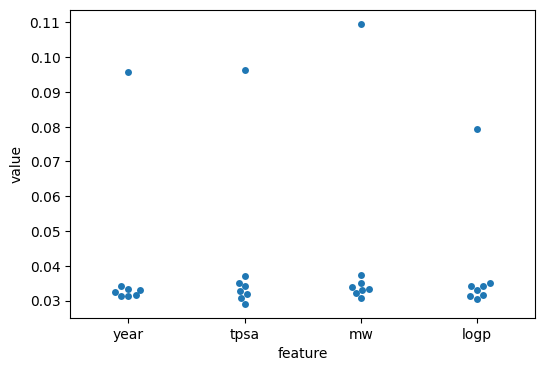

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame(homophily_labels, columns=["id", "value", "feature"])
# swarmplot
plt.figure(figsize=(6, 4))
sns.swarmplot(x="feature", y="value", data=df)
# plt.savefig("../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/homophily_labels.png", dpi=300)

In [13]:
import os
import pickle
import pandas as pd
import numpy as np
import collections
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm

# --- 設定 ---
num_permutations = 100  # 試行回数

print("Starting Homophily Analysis...")

for i, path in enumerate(classification_paths):
    dataset_id = i
    tdc_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc"
    output_folder_path = f"{tdc_path}/{os.path.basename(path).replace('_date.tsv', '')}"
    # os.makedirs(output_folder_path, exist_ok=True)
    
    print(f"Processing Dataset {dataset_id}: {os.path.basename(path)}")

    # データのロード
    try:
        s = pickle_load(os.path.join(output_folder_path, "s.pkl"))
        t = pickle_load(os.path.join(output_folder_path, "t.pkl"))
        df = pd.read_csv(path, sep='\t')
    except FileNotFoundError as e:
        break

    years_list = []
    tpsa, mw, logp = [], [], []
    
    for j in range(len(df)):
        y = int(df.iloc[j, 2])
        years_list.append(y)
        mol = Chem.MolFromSmiles(df.iloc[j, 0])
        if mol:
            tpsa.append(Descriptors.TPSA(mol))
            mw.append(Descriptors.MolWt(mol))
            logp.append(Descriptors.MolLogP(mol))
        else:
            tpsa.append(0); mw.append(0); logp.append(0)

    # --- Yearの頻度分布の計算 ---
    counter_year = collections.Counter(years_list)
    counter_year_keys = sorted(list(counter_year.keys()))
    count_distribution = []
    for key in counter_year_keys:
        count_distribution.append(counter_year[key])

    # --- 描画用にデータを蓄積するリスト ---
    plot_labels = []      # X軸のラベル (Year, MW etc.)
    plot_nulls = []       # 帰無分布のリストのリスト
    plot_reals = []       # 実測値のリスト

    target_features = [
        (years_list, "Year"), 
        (tpsa, "TPSA"), 
        (mw, "MW"), 
        (logp, "LogP")
    ]

    # --- 分析ループ ---
    for data, label_type in target_features:
        
        # ラベル生成 (Year以外はビン分割)
        if label_type == "Year":
            labels = np.array(data)
        else:
            sorted_data_index = sorted(range(len(data)), key=lambda k: data[k])
            data_label = [0 for _ in range(len(data))]
            label_val = 0
            index = 0
            for count in count_distribution:
                index_next = index + count
                for j in range(index, index_next):
                    data_label[sorted_data_index[j]] = label_val
                index = index_next
                label_val += 1
            labels = np.array(data_label)

        # 実測HR
        lsh_purity_real = lsh_forest_purity(s, t, labels)

        # 帰無分布 (Permutation)
        random_purities = []
        for perm in range(num_permutations):
            shuffled_labels = np.random.RandomState(seed=perm).permutation(labels)
            random_purity = lsh_forest_purity(s, t, shuffled_labels)
            random_purities.append(random_purity)
        
        # 描画用リストに追加
        plot_labels.append(label_type)
        plot_nulls.append(random_purities)
        plot_reals.append(lsh_purity_real)

        # Pickle保存 (省略せず残します)
        result_data = {
            "dataset_id": dataset_id,
            "feature": label_type,
            "real_hr": lsh_purity_real,
            "null_distribution": random_purities,
            "p_value": np.mean(np.array(random_purities) >= lsh_purity_real)
        }
        pickle_path = os.path.join(output_folder_path, f"homophily_data_{label_type}.pkl")
        with open(pickle_path, "wb") as f:
            pickle.dump(result_data, f)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150) # 高画質化

    bp = ax.boxplot(
        plot_nulls,
        labels=plot_labels,
        patch_artist=True, # 箱の中を塗る
        widths=0.4,        # 箱の幅
        showfliers=True,   # 外れ値を表示(画像に合わせて点にする)
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                        linestyle='none', markeredgecolor='none', alpha=0.6)
    )

    # Box Plotのスタイル詳細設定 (画像に合わせる)
    for patch in bp['boxes']:
        patch.set_facecolor('#D3D3D3') # 薄いグレー (LightGray)
        patch.set_edgecolor('#555555') # 枠は濃いグレー
        patch.set_linewidth(1)
    
    for element in ['whiskers', 'caps']:
        plt.setp(bp[element], color='#555555', linewidth=1)
    
    plt.setp(bp['medians'], color='black', linewidth=1.5) # 中央値は黒ではっきり

    # 2. 実測値 (Real HR) - 青い大きな丸
    # boxplotは1, 2, 3... の位置にプロットされるので x=i+1
    for idx, real_val in enumerate(plot_reals):
        ax.scatter(
            idx + 1, 
            real_val, 
            color='#4169E1',   # RoyalBlue (鮮やかな青)
            s=180,             # サイズ大きく
            edgecolor='black', # 黒い縁取り
            linewidth=1.2,
            zorder=10,         # 最前面に表示
            label="Real Value" if idx == 0 else None
        )

    # 3. 全体デザイン調整
    ax.set_title("Homophily Ratio: Observed vs Null Distributions", fontsize=16, pad=15)
    ax.set_ylabel("Homophily Ratio", fontsize=14)
    
    # グリッド (点線・薄め)
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='lightgray')
    ax.grid(axis='x', linestyle='--', alpha=0.6, color='lightgray') # 画像に合わせて縦グリッドも入れる場合

    # 上と右の枠線を消す (Spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 軸の色を少しマイルドに
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    
    # フォントサイズ調整
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    
    # 保存
    save_path = os.path.join(output_folder_path, "homophily_boxplot_style.png")
    plt.savefig(save_path)
    plt.close() # 連続処理のため閉じる

    print(f"Saved plot to {save_path}")

print("Done.")

Starting Homophily Analysis...
Processing Dataset 0: 3_HIV_date.tsv


/tmp/ipykernel_108121/388738060.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved plot to ../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/3_HIV/homophily_boxplot_style.png
Processing Dataset 1: 4_orexin1_receptor_butkiewicz_date.tsv


/tmp/ipykernel_108121/388738060.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved plot to ../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_orexin1_receptor_butkiewicz/homophily_boxplot_style.png
Processing Dataset 2: 5_m1_muscarinic_receptor_agonists_butkiewicz_date.tsv


/tmp/ipykernel_108121/388738060.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved plot to ../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/5_m1_muscarinic_receptor_agonists_butkiewicz/homophily_boxplot_style.png
Processing Dataset 3: 9_cav3_t-type_calcium_channels_butkiewicz_date.tsv


/tmp/ipykernel_108121/388738060.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved plot to ../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/9_cav3_t-type_calcium_channels_butkiewicz/homophily_boxplot_style.png
Processing Dataset 4: 11_serine_threonine_kinase_33_butkiewicz_date.tsv


KeyboardInterrupt: 

In [12]:
plot_reals

[np.float64(0.03138048297533468),
 np.float64(0.033446687615685936),
 np.float64(0.03194008006542982),
 np.float64(0.031724850415393226)]

# search compound in network

In [23]:
import pandas as pd
df = pd.read_csv("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/processed/tdc/Tox/4_hERG_Karim_date.tsv", sep="\t", header=0, names=["smiles", "tox", "year"])
df = df.sort_values(by="year").reset_index(drop=True)

import pickle
s = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/s.pkl", "rb"))
t = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/t.pkl", "rb"))
x = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/x.pkl", "rb"))
y = pickle.load(open("/workspace/HDD1/user/ohto/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/4_hERG_Karim/y.pkl", "rb"))

In [24]:
smiles = 'Cc1ncc(OC[C@@]2(c3cccc(F)c3)C[C@H]2C(=O)Nc2cc(C)c(F)cn2)c(C)n1'
for i in range(len(df)):
    if df.iloc[i,0] == smiles:
        matched_index = i
        print(i)
        print(df.iloc[i])
        break

5284
smiles    Cc1ncc(OC[C@@]2(c3cccc(F)c3)C[C@H]2C(=O)Nc2cc(...
tox                                                       0
year                                               2012.301
Name: 5284, dtype: object


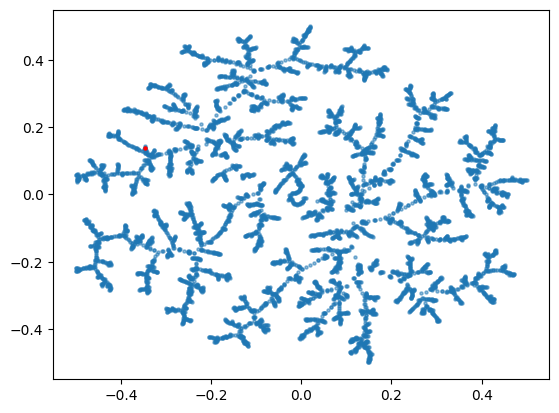

In [25]:
from matplotlib import pyplot as plt
plt.scatter(x, y, alpha=0.5, s=5)
plt.scatter(x[matched_index], y[matched_index], color='red', s=5 )

In [33]:
smiles = [df.iloc[i,0] for i in range(len(df))]
years = [int(df.iloc[i,2]) for i in range(len(df))]
target_smiles = 'Cc1ncc(OC[C@@]2(c3cccc(F)c3)C[C@H]2C(=O)Nc2cc(C)c(F)cn2)c(C)n1'

In [34]:
for i in range(len(smiles)):
    if smiles[i] == target_smiles:
        index = i
print(index)

5284


In [35]:
neighbors_1 = []
for i in range(len(s)):
    if s[i] == index:
        neighbors_1.append(t[i])
    if t[i] == index:
        neighbors_1.append(s[i])
neighbors_1 = list(set(neighbors_1))
print(neighbors_1)

neighbors_2 = []
for i in range(len(s)):
    if s[i] in neighbors_1:
        neighbors_2.append(t[i])
    if t[i] in neighbors_1:
        neighbors_2.append(s[i])
neighbors_2 = list(set(neighbors_2))
print(neighbors_2)

neighbors_3 = []
for i in range(len(s)):
    if s[i] in neighbors_2:
        neighbors_3.append(t[i])
    if t[i] in neighbors_2:
        neighbors_3.append(s[i])
neighbors_3 = list(set(neighbors_3))
print(neighbors_3)


neighbors_4 = []
for i in range(len(s)):
    if s[i] in neighbors_3:
        neighbors_4.append(t[i])
    if t[i] in neighbors_3:
        neighbors_4.append(s[i])
neighbors_4 = list(set(neighbors_4))
print(neighbors_4)

neighbors_5 = []
for i in range(len(s)):
    if s[i] in neighbors_4:
        neighbors_5.append(t[i])
    if t[i] in neighbors_4:
        neighbors_5.append(s[i])
neighbors_5 = list(set(neighbors_5))
print(neighbors_5)

neighbors_6 = []
for i in range(len(s)):
    if s[i] in neighbors_5:
        neighbors_6.append(t[i])
    if t[i] in neighbors_5:
        neighbors_6.append(s[i])
neighbors_6 = list(set(neighbors_6))
print(neighbors_6)

[5283, 5277]
[5282, 970, 5284, 5274]
[5281, 5283, 5277, 5286]
[5282, 5284, 970, 1618, 5274, 5279]
[5281, 4450, 5283, 5286, 4330, 3467, 1626, 5277]
[4290, 5282, 4420, 5284, 4422, 5274, 4424, 970, 4460, 4463, 1618, 4437, 4311, 4474, 1627, 5279]


In [47]:
neighbors_smiles = []
for i in range(len(smiles)):
    if i in neighbors_1 or i in neighbors_2 or i in neighbors_3 or i in neighbors_4 or i in neighbors_5 or i in neighbors_6:
        neighbors_smiles.append(smiles[i])
    elif smiles[i] == target_smiles:
        neighbors_smiles.append(smiles[i])

        
neighbors_years = []
for i in range(len(years)):
    if i in neighbors_1 or i in neighbors_2 or i in neighbors_3 or i in neighbors_4 or i in neighbors_5 or i in neighbors_6:
        neighbors_years.append(str(years[i]))
    elif i == target_smiles:
        neighbors_years.append(str(years[i]))

In [51]:
neighbors_numbers = []

for i in range(len(smiles)):
    if smiles[i] == target_smiles:
        neighbors_numbers.append("0")
    elif i in neighbors_1:
        neighbors_numbers.append("1")
    elif i in neighbors_2:
        neighbors_numbers.append("2")
    elif i in neighbors_3:
        neighbors_numbers.append("3")
    elif i in neighbors_4:
        neighbors_numbers.append("4")
    elif i in neighbors_5:
        neighbors_numbers.append("5")
    elif i in neighbors_6:
        neighbors_numbers.append("6")

In [52]:
from rdkit.Chem import Draw

options = Draw.MolDrawOptions()
options.legendFontSize = 40   # default: 16
options.legendFraction = 0.2   # default: 0.1

mols = [Chem.MolFromSmiles(smiles) for smiles in neighbors_smiles]

grid_img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,  
    subImgSize=(400, 400),
    drawOptions=options, 
    legends=neighbors_numbers,
)

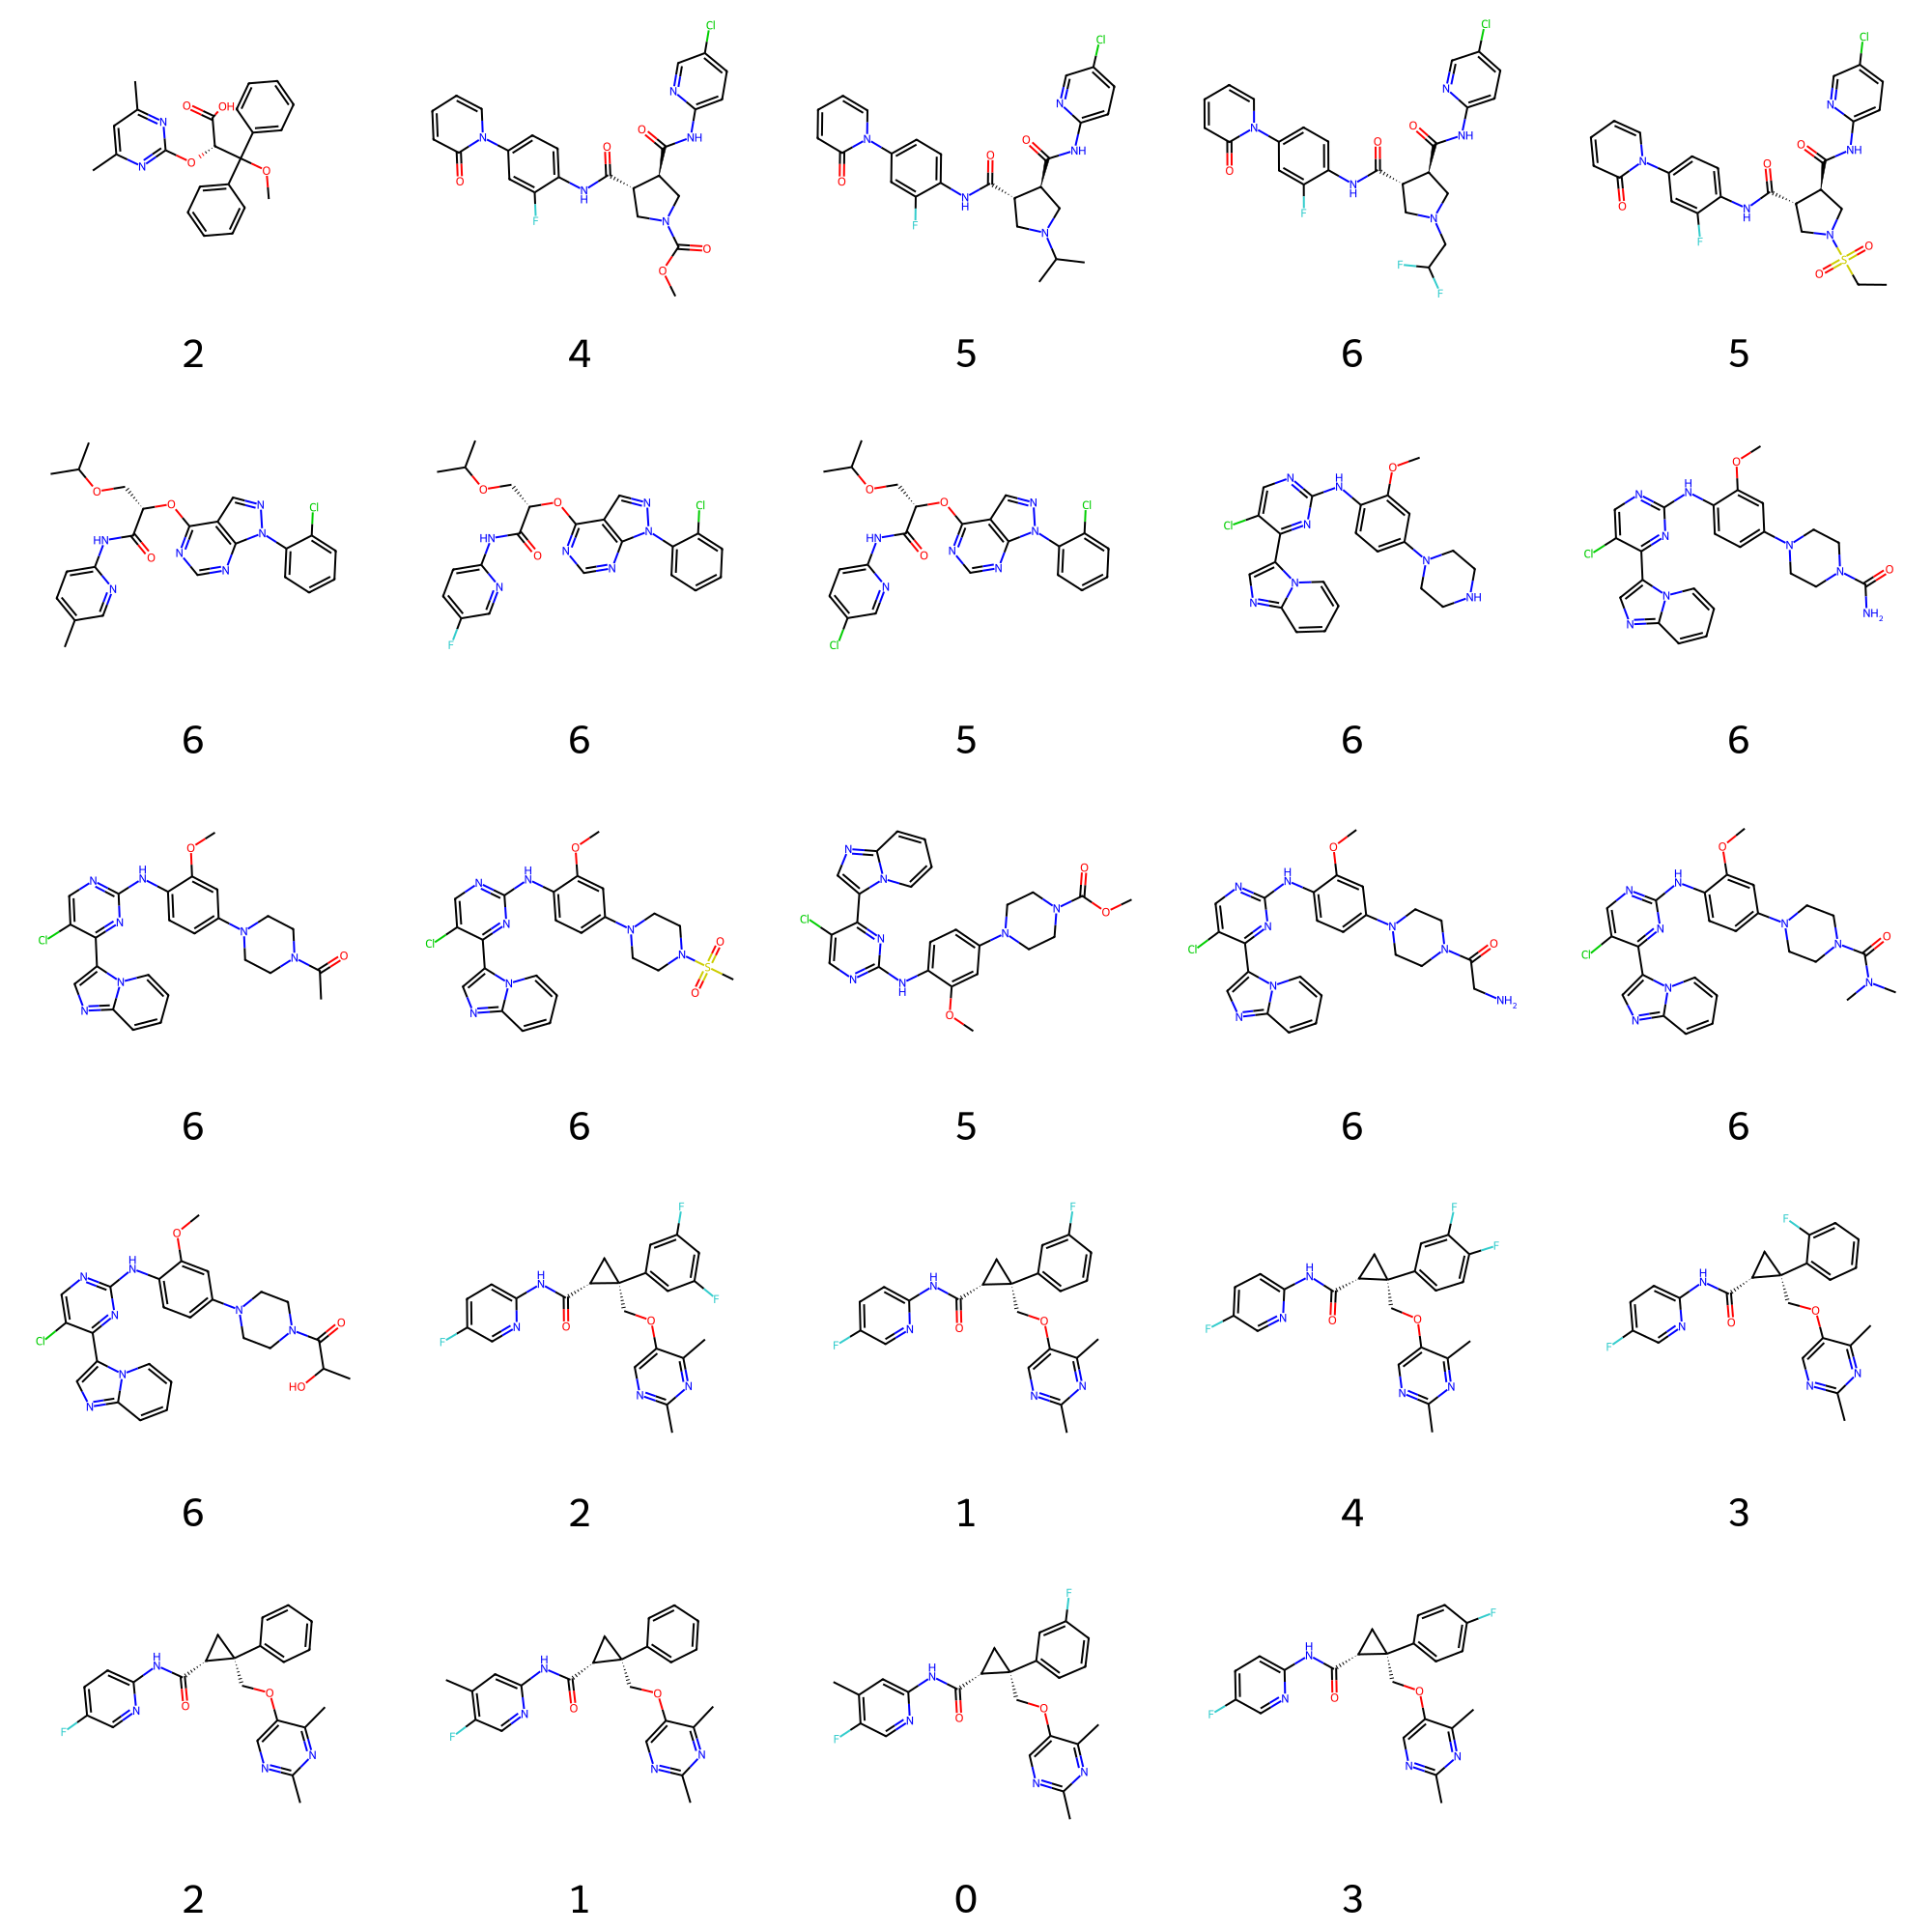

In [53]:
grid_img